# Gastrointestinal Disease Classification Pipeline
End-to-end deep learning pipeline for GI disease classification using WCE images.
Train: Kvasir-Capsule (local, imbalanced) | Test: Kvasir-V2 (HuggingFace streaming, balanced)

## Cell 1 — Imports and Seeds

In [1]:
import os
import glob
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
import tensorflow as tf
from tensorflow.keras import layers, regularizers, models
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, ResNet101V2
from tensorflow.keras.callbacks import ReduceLROnPlateau, LearningRateScheduler
from datasets import load_dataset
from PIL import Image
from IPython.display import display

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
AUTOTUNE = tf.data.AUTOTUNE

print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

ModuleNotFoundError: No module named 'tensorflow'

## TASK 1 — Dataset Exploration and Imbalance Analysis

In [2]:
df_kvasir = pd.read_csv('/kaggle/input/datasets/skdeeraj/kvasir-dataset/df_baseline.csv')
df_under  = pd.read_csv('/kaggle/input/datasets/skdeeraj/kvasir-dataset/df_undersampled.csv')
df_over   = pd.read_csv('/kaggle/input/datasets/skdeeraj/kvasir-dataset/df_oversampled.csv')

df_kvasir['aug'] = df_kvasir['aug'].astype(bool)
df_under['aug']  = df_under['aug'].astype(bool)
df_over['aug']   = df_over['aug'].astype(bool)


In [3]:
BASE_DATASET = "/kaggle/input/datasets/skdeeraj/kvasir-zip"


for item in os.listdir(BASE_DATASET):
    print(item)

kvasir_capsule_extracted


In [4]:
# ============================================================
# CONFIG — update DATA_DIR if running on Kaggle
# ============================================================
DATA_DIR    = "/kaggle/input/datasets/skdeeraj/kvasir-zip/kvasir_capsule_extracted"  # local
IMG_SIZE    = (224, 224)
CHANNELS    = 3
BATCH_SIZE  = 32
IMAGE_EXTS  = {".jpg", ".jpeg", ".png", ".bmp"}

# ============================================================
# Build DataFrame — handles nested same-name subfolder layout
# kvasir_capsule_extracted/class_name/class_name/*.jpg
# ============================================================
def find_image_dir(cls_path, cls_name):
    """Resolve the actual image folder regardless of flat vs nested layout."""
    # Check flat: root/cls/*.jpg
    flat = [f for f in glob.glob(os.path.join(cls_path, '*'))
            if os.path.isfile(f) and os.path.splitext(f)[1].lower() in IMAGE_EXTS]
    if flat:
        return cls_path
    # Check nested same-name: root/cls/cls/*.jpg
    nested = os.path.join(cls_path, cls_name)
    if os.path.isdir(nested):
        return nested
    # Fallback: any single subdirectory
    subdirs = [d for d in os.scandir(cls_path) if d.is_dir()]
    if len(subdirs) == 1:
        return subdirs[0].path
    return cls_path


def build_kvasir_capsule_df(data_dir):
    rows = []
    for cls in sorted(os.listdir(data_dir)):
        cls_path = os.path.join(data_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        img_dir = find_image_dir(cls_path, cls)
        imgs = [f for f in glob.glob(os.path.join(img_dir, '*'))
                if os.path.isfile(f) and os.path.splitext(f)[1].lower() in IMAGE_EXTS]
        for fp in imgs:
            rows.append({'path': fp, 'label': cls})
    df = pd.DataFrame(rows)
    return df


df_kvasir = build_kvasir_capsule_df(DATA_DIR)

# Sanity checks
assert len(df_kvasir) > 14, f"Only {len(df_kvasir)} rows — nested folder not resolved correctly"

print(f"Total images loaded: {len(df_kvasir)}")
print(f"\nPer-class count:")
print(df_kvasir['label'].value_counts().to_string())

# Derive class names from the loaded data
class_names  = sorted(df_kvasir['label'].unique().tolist())
num_classes  = len(class_names)
class_to_idx = {name: i for i, name in enumerate(class_names)}
print(f"\nClasses ({num_classes}): {class_names}")

Total images loaded: 47238

Per-class count:
label
normal_clean_mucosa     34338
ileocecal_valve          4189
reduced_mucosal_view     2906
pylorus                  1529
angiectasia               866
ulcer                     854
foreign_body              776
lymphangiectasia          592
erosion                   506
blood_fresh               446
erythema                  159
polyp                      55
blood_hematin              12
ampulla_of_vater           10

Classes (14): ['ampulla_of_vater', 'angiectasia', 'blood_fresh', 'blood_hematin', 'erosion', 'erythema', 'foreign_body', 'ileocecal_valve', 'lymphangiectasia', 'normal_clean_mucosa', 'polyp', 'pylorus', 'reduced_mucosal_view', 'ulcer']


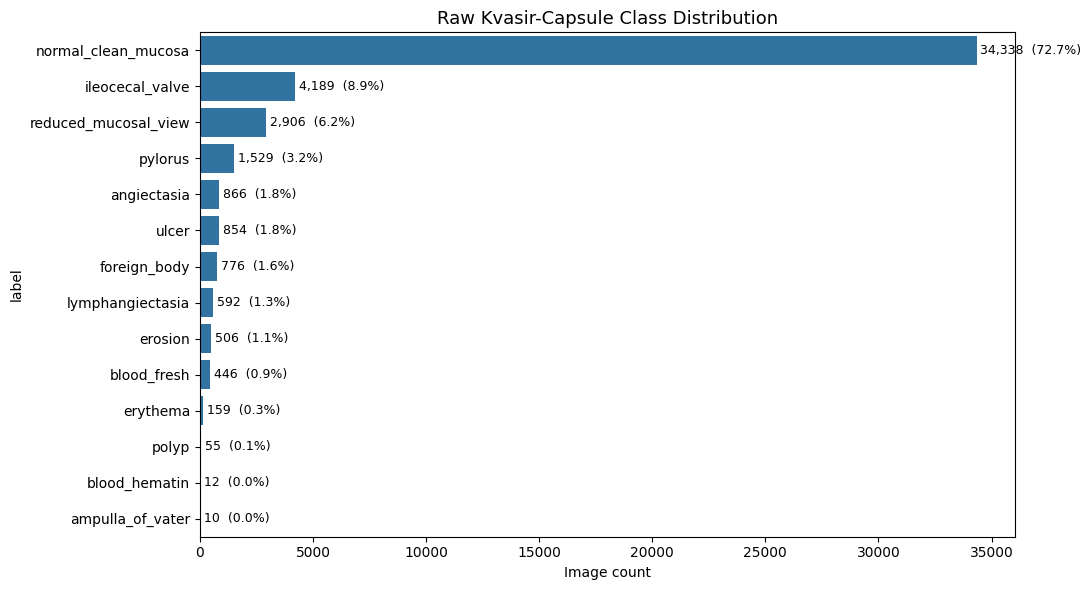

Majority : normal_clean_mucosa  (34,338 samples)
Minority : ampulla_of_vater  (10 samples)
Imbalance ratio : 3433.8x
Gini Impurity   : 0.4576  (0 = perfect imbalance, 1 = perfect balance)
Shannon Entropy : 1.6173  (max for 14 classes = 3.8074)


In [5]:
# ============================================================
# Distribution plot
# ============================================================
def plot_distribution(df, title):
    counts = df['label'].value_counts().sort_values(ascending=False)
    ratios = counts / len(df)
    plt.figure(figsize=(11, 6))
    sns.barplot(x=counts.values, y=counts.index, orient='h')
    for i, (count, pct) in enumerate(zip(counts.values, ratios.values)):
        plt.text(count + counts.max() * 0.005, i,
                 f"{count:,}  ({pct:.1%})", va='center', fontsize=9)
    plt.title(title, fontsize=13)
    plt.xlabel('Image count')
    plt.tight_layout()
    plt.show()
    return counts, ratios


counts, ratios = plot_distribution(df_kvasir, "Raw Kvasir-Capsule Class Distribution")

majority_class = counts.index[0]
minority_class = counts.index[-1]
imbalance_ratio = counts.iloc[0] / counts.iloc[-1]

gini    = 1 - float((ratios ** 2).sum())
entropy = float(-(ratios * np.log2(ratios + 1e-10)).sum())

print(f"Majority : {majority_class}  ({counts.iloc[0]:,} samples)")
print(f"Minority : {minority_class}  ({counts.iloc[-1]:,} samples)")
print(f"Imbalance ratio : {imbalance_ratio:.1f}x")
print(f"Gini Impurity   : {gini:.4f}  (0 = perfect imbalance, 1 = perfect balance)")
print(f"Shannon Entropy : {entropy:.4f}  (max for 14 classes = {math.log2(14):.4f})")

### Imbalance Discussion

1. **Why imbalance occurs:** The capsule spends ~70% of transit time in normal mucosa; rare pathologies like angiectasia or ampulla of Vater appear in <0.1% of frames, creating a natural anatomical imbalance.
2. **Why accuracy misleads:** A model predicting only `normal_clean_mucosa` achieves ~70%+ accuracy while completely failing on all pathologies — accuracy is therefore a vacuous metric here.
3. **Clinical cost of false negatives:** Missed angiectasia causes undetected GI bleeding; missed polyps miss early cancer detection — false negatives on minority classes are clinically catastrophic.
4. **Correct metrics:** F1-macro and per-class recall weight all classes equally regardless of sample count, directly measuring sensitivity on rare pathologies.
5. **Data-level vs algorithm-level:** Sampling changes the data distribution seen during training; cost-sensitive loss (class weights) penalises misclassification of minority classes in the gradient — both attack different parts of the learning pipeline.
6. **Combined approach:** Under-sampling + augmentation + class-weighted loss together address gradient skew, feature scarcity, and overfitting simultaneously — no single technique is sufficient alone.

## TASK 2 — Random Under-Sampling (majority class control)

UNDER_CAP (median class count): 684
Before under-sampling : 47,238 rows
After under-sampling  : 6,568 rows
Data discarded        : 86.10%

Per-class after under-sampling:
label
foreign_body            684
reduced_mucosal_view    684
ileocecal_valve         684
ulcer                   684
pylorus                 684
angiectasia             684
normal_clean_mucosa     684
lymphangiectasia        592
erosion                 506
blood_fresh             446
erythema                159
polyp                    55
blood_hematin            12
ampulla_of_vater         10


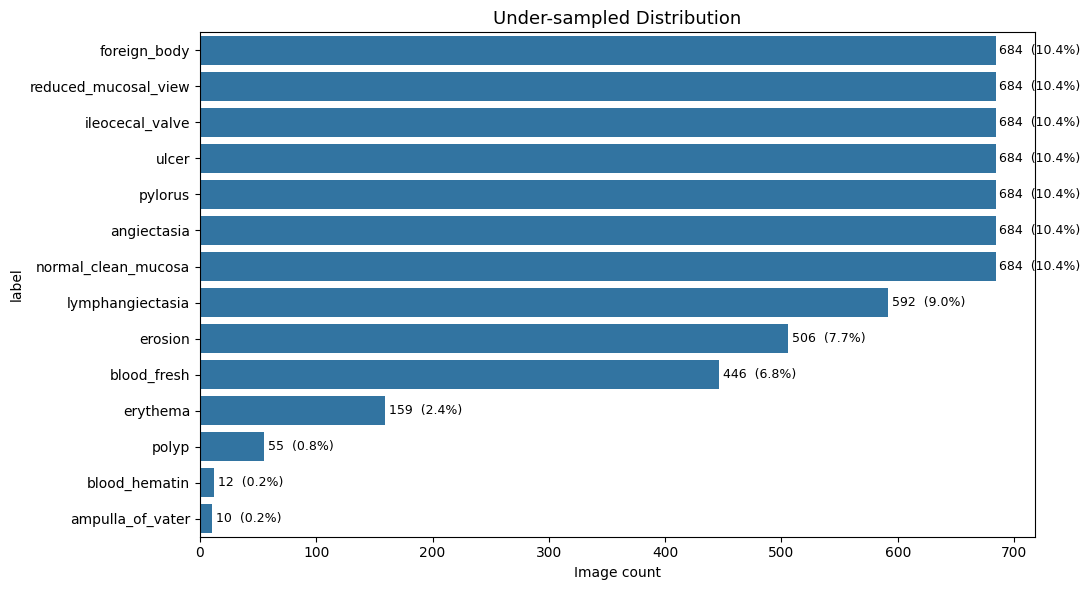

In [6]:
# REASON: Use median count as cap — it preserves the natural data regime of
# mid-tier classes instead of collapsing everything to the rarest pathology.
# Hardcoding 200 would discard ~99% of normal_clean_mucosa while still leaving
# a massive gap vs classes with only 10–20 images.
UNDER_CAP = int(counts.median())
print(f"UNDER_CAP (median class count): {UNDER_CAP}")

def undersample_df(df, cap):
    """
    Random under-sampling: cap MAJORITY classes at `cap`.
    Minority classes (below cap) are kept fully intact.
    """
    parts = []
    for lbl, group in df.groupby('label'):
        if len(group) > cap:
            # MAJORITY: randomly sample down to cap
            parts.append(group.sample(n=cap, random_state=SEED))
        else:
            # MINORITY: keep all samples untouched
            parts.append(group)
    return pd.concat(parts).sample(frac=1, random_state=SEED).reset_index(drop=True)


df_under = undersample_df(df_kvasir, UNDER_CAP)

print(f"Before under-sampling : {len(df_kvasir):,} rows")
print(f"After under-sampling  : {len(df_under):,} rows")
print(f"Data discarded        : {(1 - len(df_under)/len(df_kvasir))*100:.2f}%")
print(f"\nPer-class after under-sampling:")
print(df_under['label'].value_counts().to_string())

_, _ = plot_distribution(df_under, "Under-sampled Distribution")

**Observation:**
Under-sampling significantly reduces the dominant `normal_clean_mucosa` and `ileocecal_valve` classes, creating a more balanced gradient signal during training.
The tradeoff is substantial data loss from majority classes; however, minority classes retain all original samples, preserving the scarce pathological features the model must learn.
The median-based cap ensures mid-tier classes lose minimal data while majority classes are brought in line.

## TASK 3 — Augmentation-Based Over-Sampling (minority classes only)

In [7]:
# ============================================================
# AUGMENTATION PIPELINE
# All fill_mode="reflect" to avoid black border artifacts from
# the endoscope lens vignette merging with translation fill.
# ============================================================

# ---- Novel Augmentation 1: CutOut / Random Erasing ----
# REASON: Simulates partial occlusion from mucus/debris/bubbles
# which are real imaging artifacts in WCE frames.
class CutOut(tf.keras.layers.Layer):
    def __init__(self, mask_size=30, **kwargs):
        super().__init__(**kwargs)
        self.mask_size = mask_size

    def call(self, x, training=None):
        if not training:
            return x
        # x can be (H, W, C) or (B, H, W, C) — handle both
        shape = tf.shape(x)
        is_batched = (len(x.shape) == 4)
        img_h = shape[1] if is_batched else shape[0]
        img_w = shape[2] if is_batched else shape[1]
        ms    = self.mask_size

        # Clamp mask_size to actual image dimensions
        ms    = tf.minimum(ms, tf.minimum(img_h - 1, img_w - 1))

        y0 = tf.random.uniform((), 0, img_h - ms, dtype=tf.int32)
        x0 = tf.random.uniform((), 0, img_w - ms, dtype=tf.int32)

        ys = tf.range(y0, y0 + ms)
        xs = tf.range(x0, x0 + ms)
        gy, gx = tf.meshgrid(ys, xs, indexing='ij')
        coords = tf.stack([tf.reshape(gy, [-1]), tf.reshape(gx, [-1])], axis=1)

        if is_batched:
            # Apply to each image in batch independently
            def apply_to_single(img):
                c = tf.shape(img)[2]
                zeros = tf.zeros([ms * ms, c], dtype=img.dtype)
                return tf.tensor_scatter_nd_update(img, coords, zeros)
            return tf.map_fn(apply_to_single, x)
        else:
            c = tf.shape(x)[2]
            zeros = tf.zeros([ms * ms, c], dtype=x.dtype)
            return tf.tensor_scatter_nd_update(x, coords, zeros)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'mask_size': self.mask_size})
        return cfg


# ---- Novel Augmentation 2: Gaussian Noise Injection ----
# REASON: WCE cameras have sensor noise; injecting calibrated noise
# (stddev=0.02 ≈ 5/255) improves robustness to real hardware variation
# without degrading pathological texture visibility.
class GaussianNoise(tf.keras.layers.Layer):
    def __init__(self, stddev=0.02, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev

    def call(self, x, training=None):
        if not training:
            return x
        noise = tf.random.normal(tf.shape(x), stddev=self.stddev)
        return tf.clip_by_value(x + noise, 0.0, 1.0)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'stddev': self.stddev})
        return cfg


# Full augmentation pipeline applied during decode for minority-class rows
# All operations on single images (H, W, C) — batching happens in make_ds
augmentation_pipeline = tf.keras.Sequential([
    # REASON: No anatomical left-right axis in WCE; flipping is label-preserving
    layers.RandomFlip('horizontal'),
    # REASON: Capsule tumbles freely in GI tract; reflect fill avoids black vignette artifacts
    layers.RandomRotation(0.15, fill_mode='reflect'),
    # REASON: Capped at 0.1 (not 0.2) to avoid cropping the diagnostic region of interest
    layers.RandomTranslation(0.1, 0.1, fill_mode='reflect'),
    # REASON: Simulates varying capsule-to-mucosa wall distance
    layers.RandomZoom(0.15, fill_mode='reflect'),
    # REASON: Adjusts for varying GI LED illumination intensity between frames
    layers.RandomContrast(0.15),
    # Novel 1: CutOut — simulates mucus/debris occlusion
    CutOut(mask_size=30),
    # Novel 2: Gaussian noise — simulates WCE sensor noise
    GaussianNoise(stddev=0.02),
], name='augmentation_pipeline')

print("Augmentation pipeline built.")

Augmentation pipeline built.


I0000 00:00:1774377518.287919      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


After over-sampling: 9,576 rows
  Originals (aug=False): 6,568
  Duplicates (aug=True): 3,008

Per-class after over-sampling:
label
blood_fresh             684
ileocecal_valve         684
angiectasia             684
blood_hematin           684
reduced_mucosal_view    684
ampulla_of_vater        684
lymphangiectasia        684
foreign_body            684
ulcer                   684
erosion                 684
erythema                684
pylorus                 684
normal_clean_mucosa     684
polyp                   684


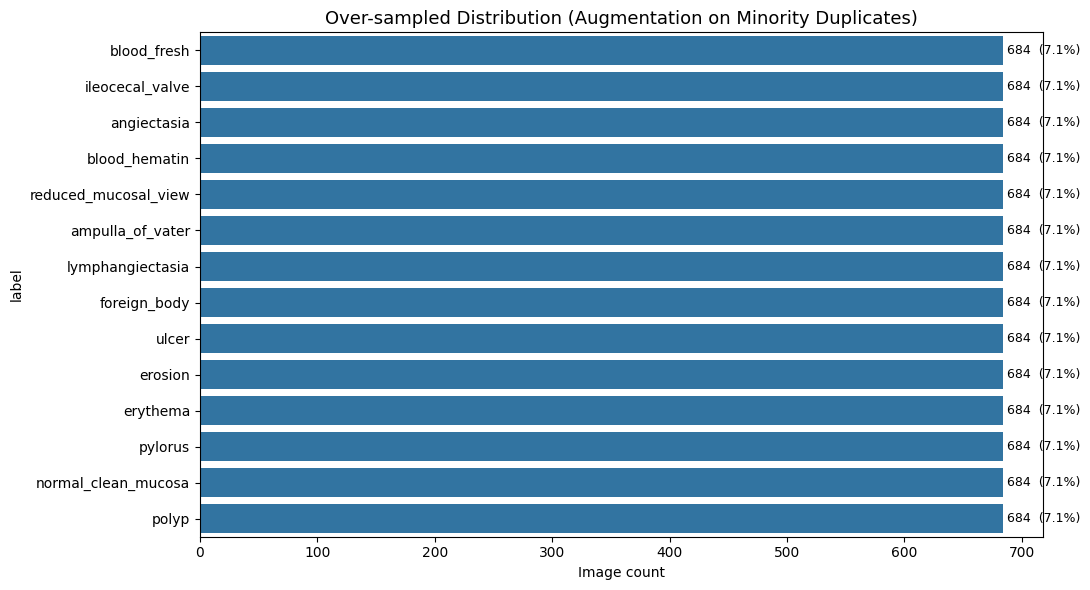

In [8]:
# ============================================================
# Over-sampling via row duplication — augmentation applied at
# decode time ONLY for duplicated (minority) rows.
# Strategy:
#   1. Start from df_under (majority already capped)
#   2. For each class below UNDER_CAP: duplicate rows with
#      replacement until it reaches UNDER_CAP
#   3. Mark duplicated rows with aug=True
#   4. Original rows keep aug=False
# This ensures augmentation is applied ONLY to minority class
# duplicates, not to majority class originals.
# ============================================================

def oversample_minority_df(df_undersampled, target):
    """
    Over-sample minority classes up to `target` by duplicating rows.
    Adds an 'aug' column: True for duplicated rows (will be augmented
    at decode time), False for original rows.

    Input: df_undersampled — already under-sampled DataFrame
    Only classes with fewer than `target` samples are over-sampled.
    """
    df = df_undersampled.copy()
    df['aug'] = False  # mark all originals as non-augmented

    parts = [df]  # start with all originals
    for lbl, group in df.groupby('label'):
        if len(group) < target:
            needed = target - len(group)
            # Sample with replacement from the minority class originals
            extra = group.sample(n=needed, replace=True, random_state=SEED).copy()
            extra['aug'] = True  # these duplicates WILL be augmented
            parts.append(extra)

    result = pd.concat(parts).sample(frac=1, random_state=SEED).reset_index(drop=True)
    return result


df_over = oversample_minority_df(df_under, UNDER_CAP)

print(f"After over-sampling: {len(df_over):,} rows")
print(f"  Originals (aug=False): {(~df_over['aug']).sum():,}")
print(f"  Duplicates (aug=True): {df_over['aug'].sum():,}")
print(f"\nPer-class after over-sampling:")
print(df_over['label'].value_counts().to_string())

_, _ = plot_distribution(df_over, "Over-sampled Distribution (Augmentation on Minority Duplicates)")

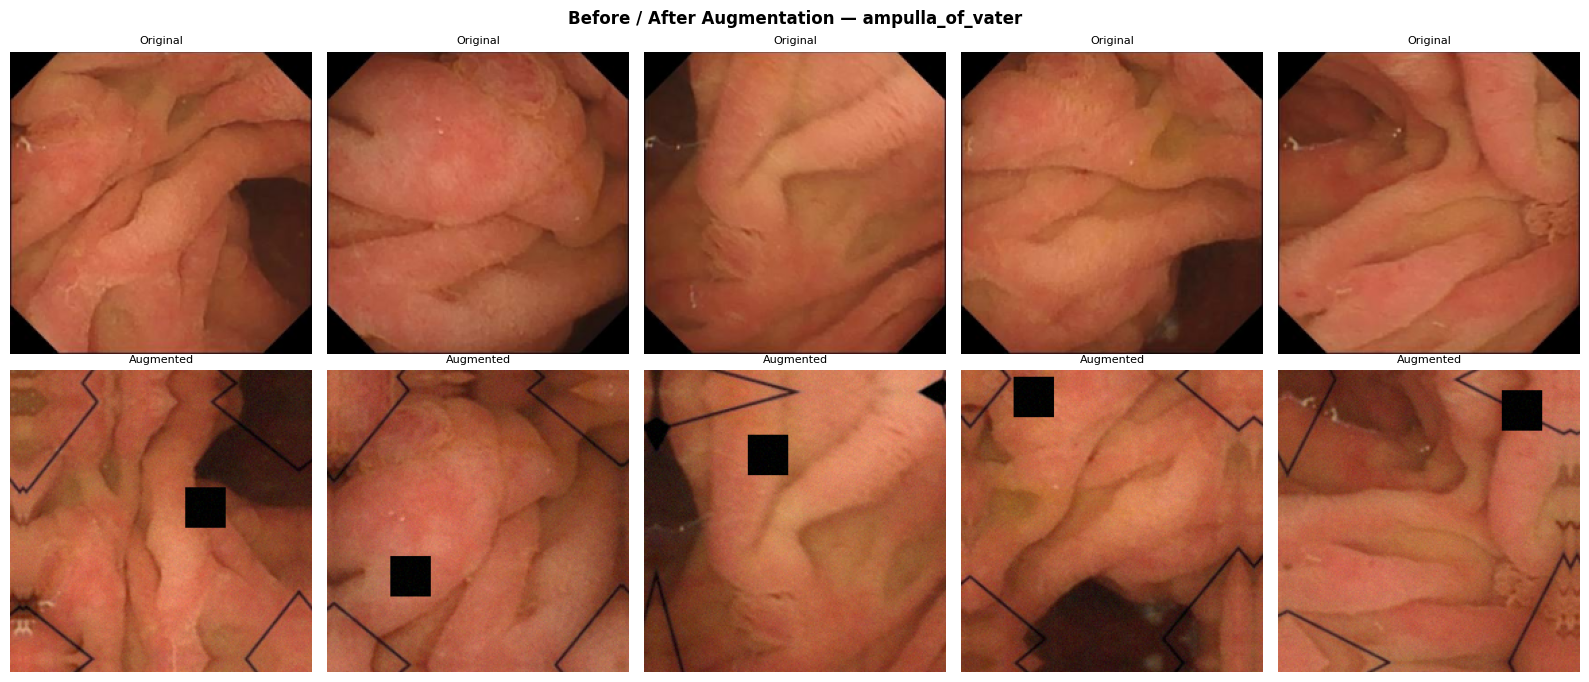


Dataset size summary:
  Baseline (raw)       :   47,238 images
  Under-sampled        :    6,568 images
  Under + Over-sampled :    9,576 images


In [9]:
# ============================================================
# Before/After augmentation preview for rarest class
# ============================================================
def display_augmented_samples(df_source, class_name, num_samples=5):
    subset = df_source[df_source['label'] == class_name].drop_duplicates('path').head(num_samples)
    fig, axes = plt.subplots(2, len(subset), figsize=(3 * len(subset) + 1, 7))
    if len(subset) == 1:
        axes = [[axes[0]], [axes[1]]]

    for i, (_, row) in enumerate(subset.iterrows()):
        raw = tf.io.read_file(row['path'])
        raw = tf.image.decode_jpeg(raw, channels=3)
        raw = tf.image.resize(raw, IMG_SIZE)
        raw = tf.cast(raw, tf.float32) / 255.0

        # Augmented: expand_dims for pipeline, squeeze back
        aug_img = augmentation_pipeline(
            tf.expand_dims(raw, 0), training=True)[0]

        axes[0][i].imshow(raw.numpy())
        axes[0][i].set_title('Original', fontsize=8)
        axes[0][i].axis('off')

        axes[1][i].imshow(aug_img.numpy())
        axes[1][i].set_title('Augmented', fontsize=8)
        axes[1][i].axis('off')

    fig.suptitle(f'Before / After Augmentation — {class_name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


display_augmented_samples(df_kvasir, 'ampulla_of_vater', num_samples=5)

print("\nDataset size summary:")
print(f"  Baseline (raw)       : {len(df_kvasir):>8,} images")
print(f"  Under-sampled        : {len(df_under):>8,} images")
print(f"  Under + Over-sampled : {len(df_over):>8,} images")

## Save DataFrames for Kaggle / External Use

In [10]:
# ============================================================
# Save the three DataFrames as CSVs.
# On Kaggle: update DATA_DIR and SAVE_DIR at the top,
# then load with pd.read_csv() — all other code is unchanged.
# df_over has an 'aug' column (bool) used by make_ds.
# df_kvasir and df_under have aug=False implicitly (no aug col).
# ============================================================

# Add aug=False column to baseline and undersampled for consistency

SAVE_DIR = "/kaggle/working/"

df_kvasir_save = df_kvasir.copy()
df_kvasir_save['aug'] = False

df_under_save = df_under.copy()
df_under_save['aug'] = False

baseline_path = os.path.join(SAVE_DIR, 'df_baseline.csv')
under_path    = os.path.join(SAVE_DIR, 'df_undersampled.csv')
over_path     = os.path.join(SAVE_DIR, 'df_oversampled.csv')

df_kvasir_save.to_csv(baseline_path, index=False)
df_under_save.to_csv(under_path,    index=False)
df_over.to_csv(over_path,           index=False)

print(f"Saved:")
print(f"  Baseline     -> {baseline_path}  ({len(df_kvasir_save):,} rows)")
print(f"  Under-sampled-> {under_path}  ({len(df_under_save):,} rows)")
print(f"  Over-sampled -> {over_path}  ({len(df_over):,} rows)")
print()
print("To reload on Kaggle:")
print("  df_kvasir = pd.read_csv('df_baseline.csv')")
print("  df_under  = pd.read_csv('df_undersampled.csv')")
print("  df_over   = pd.read_csv('df_oversampled.csv')")

Saved:
  Baseline     -> /kaggle/working/df_baseline.csv  (47,238 rows)
  Under-sampled-> /kaggle/working/df_undersampled.csv  (6,568 rows)
  Over-sampled -> /kaggle/working/df_oversampled.csv  (9,576 rows)

To reload on Kaggle:
  df_kvasir = pd.read_csv('df_baseline.csv')
  df_under  = pd.read_csv('df_undersampled.csv')
  df_over   = pd.read_csv('df_oversampled.csv')


## TASK 4 — Data Preprocessing, Splitting, tf.data Pipeline

In [11]:
SPLITS = {'train': 0.70, 'val': 0.15, 'test': 0.15}

def split_df(df):
    """
    Stratified train/val/test split.
    REASON: StratifiedShuffleSplit guarantees all classes appear in every
    split — random iloc slicing can put 0 samples of a rare class in val/test.
    """
    # Drop aug column before splitting (re-added after)
    has_aug = 'aug' in df.columns
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
    train_idx, temp_idx = next(sss1.split(df, df['label']))
    train_df = df.iloc[train_idx].reset_index(drop=True)
    temp_df  = df.iloc[temp_idx].reset_index(drop=True)

    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
    val_idx, test_idx = next(sss2.split(temp_df, temp_df['label']))
    val_df  = temp_df.iloc[val_idx].reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].reset_index(drop=True)

    return train_df, val_df, test_df


# ============================================================
# Split each of the three datasets separately.
# Val and test always come from the BASELINE (real distribution)
# so evaluation reflects true clinical prevalence.
# Only the training portion varies per setting.
# ============================================================
train_baseline, val_df, test_df = split_df(df_kvasir_save)
train_under,    _,      _       = split_df(df_under_save)
train_over,     _,      _       = split_df(df_over)

print(f"Val  size : {len(val_df):,}  | Test size: {len(test_df):,}")
print(f"Train — baseline   : {len(train_baseline):,}")
print(f"Train — under      : {len(train_under):,}")
print(f"Train — under+over : {len(train_over):,}")

Val  size : 7,086  | Test size: 7,086
Train — baseline   : 33,066
Train — under      : 4,597
Train — under+over : 6,703


In [12]:
# ============================================================
# tf.data pipeline
# FIX: decode_example must NOT be decorated with @tf.function
# when `aug` is a Python bool captured in a closure — TF traces
# the function once and bakes `aug` as a constant at trace time,
# so all subsequent calls use the traced value regardless of input.
# Solution: wrap only the augmentation call in @tf.function.
# ============================================================

@tf.function(reduce_retracing=True)
def _apply_aug(img):
    """Apply augmentation pipeline to a single (H, W, C) image tensor."""
    return augmentation_pipeline(
        tf.expand_dims(img, 0), training=True)[0]


def decode_example(path, label, do_aug):
    """
    Decode one example. `do_aug` is a tf.bool tensor (0 or 1),
    derived from the 'aug' column of the DataFrame.
    tf.cond selects augmented vs raw path at graph level.
    """
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.cond(do_aug,
                  lambda: _apply_aug(img),
                  lambda: img)
    return img, label


def make_ds(df, shuffle=False):
    """
    Build a tf.data.Dataset from a DataFrame.
    The 'aug' column (bool) controls per-sample augmentation:
      - aug=True  : apply full augmentation pipeline (minority duplicates)
      - aug=False : raw decode only (originals and all val/test samples)
    """
    paths  = df['path'].values
    labels = np.array([class_to_idx[l] for l in df['label'].values], dtype=np.int32)
    augs   = df['aug'].values.astype(bool) if 'aug' in df.columns \
             else np.zeros(len(df), dtype=bool)

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels, augs.astype(np.int32))  # pass aug as int (0/1) for tf.bool
    )
    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(
        lambda p, l, a: decode_example(p, l, tf.cast(a, tf.bool)),
        num_parallel_calls=AUTOTUNE,
        deterministic=False
    )
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


# Build the four training datasets + shared val/test
train_ds_baseline = make_ds(train_baseline, shuffle=True)
train_ds_under    = make_ds(train_under,    shuffle=True)
train_ds_over     = make_ds(train_over,     shuffle=True)
val_ds            = make_ds(val_df,         shuffle=False)
test_ds           = make_ds(test_df,        shuffle=False)

# Verify batch shape
for imgs, lbls in train_ds_baseline.take(1):
    print('Baseline batch shape  :', imgs.shape)   # expect (32, 224, 224, 3)
    assert imgs.shape[1:] == (224, 224, 3)

for imgs, lbls in train_ds_over.take(1):
    print('Over-sampled batch shape:', imgs.shape)
    assert imgs.shape[1:] == (224, 224, 3)

print('\nAll datasets built successfully.')

Baseline batch shape  : (32, 224, 224, 3)
Over-sampled batch shape: (32, 224, 224, 3)

All datasets built successfully.


## TASK 5 — Transfer Learning Model Design

In [13]:
# ============================================================
# Model builder
# Using EfficientNetB0, MobileNetV2, ResNet101V2
# NOTE: InceptionV3 requires (299,299) input — using ResNet101V2
# instead to keep a consistent 224x224 input across all models.
# ============================================================

def build_model(backbone_fn, name):
    """
    backbone_fn : one of EfficientNetB0, MobileNetV2, ResNet101V2
    name        : string label for the model
    """
    base = backbone_fn(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze everything except BatchNormalization.
    # REASON: BN layers must stay in inference mode during frozen phase
    # to preserve ImageNet feature statistics. Updating BN running mean/var
    # with a small medical-image batch would corrupt the pretrained representations.
    for layer in base.layers:
        layer.trainable = isinstance(layer, layers.BatchNormalization)

    inp = layers.Input(shape=(224, 224, 3))
    x   = base(inp, training=False)  # training=False keeps BN in inference mode
    x   = layers.GlobalAveragePooling2D()(x)

    # REASON: Dropout(0.4) before dense — aggressive enough to prevent
    # the head memorising augmented minority samples.
    x = layers.Dropout(0.4)(x)

    # REASON: Dense(256) bottleneck — compresses backbone features to a
    # task-specific representation; L2(1e-4) is stronger than ImageNet
    # standard (1e-5) because our dataset is small.
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.L2(1e-4))(x)

    # REASON: Dropout(0.3) before softmax prevents overconfident predictions
    # on rare classes that have limited training samples.
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inp, outputs=outputs, name=name)
    return model, base


def print_model_summary(model):
    total      = model.count_params()
    trainable  = sum(tf.size(w).numpy() for w in model.trainable_weights)
    frozen     = total - trainable
    print(f"\n{model.name}")
    print(f"  Total params     : {total:>12,}")
    print(f"  Trainable params : {trainable:>12,}")
    print(f"  Frozen params    : {frozen:>12,}")
    print("  Last 6 layers:")
    for layer in model.layers[-6:]:
        print(f"    {layer.name:<40} trainable={layer.trainable}")


eff_model, eff_base = build_model(EfficientNetB0, 'EfficientNetB0')
mob_model, mob_base = build_model(MobileNetV2,    'MobileNetV2')
res_model, res_base = build_model(ResNet101V2,    'ResNet101V2')

for m in [eff_model, mob_model, res_model]:
    print_model_summary(m)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
171317808/171317808 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

EfficientNetB0
  Total params     :    4,381,105
  Trainable params :      373,550
  Frozen params    :    4,007,555
  Last 6 layers:
    efficientnetb0                           trainable=True
    global_average_pooling2d                 trainable=True
    dropout                                  trainable=True
    dense                                    trainable=True
    dropout_1                                trainable=True
    dense_1                                  trainable=True

MobileNetV2
  Total params     :    2,589,518
  Trainable params :      365,646
  Frozen params    :    2,223,872
  Last 6 layers:
    mobilenetv2_1.00_224                     trainable=True
    global_average_pooling2d_1               trainable=True
    dropout_2                                trainable=True
    dense_2                             

## TASK 6 — Intelligent Learning Rate Control

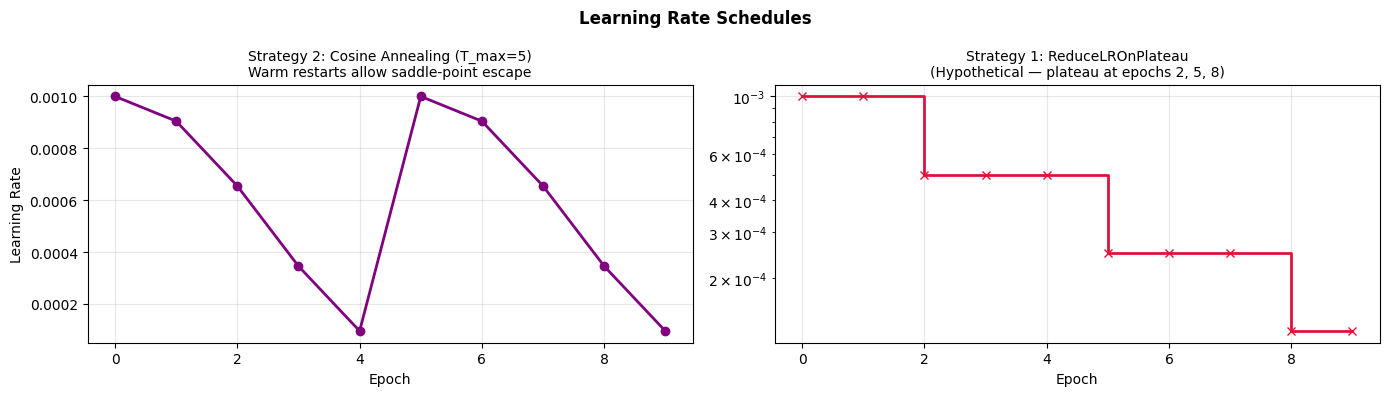

In [14]:
LR_BASE = 1e-3

# ---- Strategy 1: ReduceLROnPlateau ----
# REASON: factor=0.5 halves LR conservatively — avoids overshooting the
# shallow loss landscape of a frozen-base model.
# patience=3 avoids premature reduction due to noisy val_loss on small
# minority classes that cause high epoch-to-epoch metric variance.
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3,
    min_lr=1e-7, verbose=1
)

# ---- Strategy 2: Cosine Annealing with Warm Restarts ----
# REASON: Warm restarts help escape sharp minima caused by imbalanced
# gradients. The periodic LR reset allows re-exploration of the loss
# surface after each restart cycle, often finding flatter minima.
def cosine_schedule(epoch, lr=None, T_max=5):
    # float() is REQUIRED — keras LearningRateScheduler rejects tensors
    completed = (epoch % T_max) / T_max
    return float(LR_BASE * 0.5 * (1.0 + math.cos(math.pi * completed)))

cosine_lr = LearningRateScheduler(cosine_schedule, verbose=0)

# ---- Plot both strategies over 10 epochs ----
epochs_test = np.arange(10)
cos_lrs  = [cosine_schedule(e) for e in epochs_test]
# Simulate ReduceLROnPlateau: plateau at epoch 2, 5, 8
plat_lrs = [LR_BASE] * 2 + [LR_BASE * 0.5] * 3 + \
           [LR_BASE * 0.25] * 3 + [LR_BASE * 0.125] * 2

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_test, cos_lrs, marker='o', color='purple', linewidth=2)
axes[0].set_title('Strategy 2: Cosine Annealing (T_max=5)\nWarm restarts allow saddle-point escape', fontsize=10)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Learning Rate')
axes[0].grid(True, alpha=0.3)

axes[1].step(epochs_test, plat_lrs, where='post', marker='x', color='crimson', linewidth=2)
axes[1].set_title('Strategy 1: ReduceLROnPlateau\n(Hypothetical — plateau at epochs 2, 5, 8)', fontsize=10)
axes[1].set_xlabel('Epoch')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Learning Rate Schedules', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## TASK 7 — Training and Evaluation

In [15]:
# ============================================================
# Helpers
# ============================================================

def compile_model(model, lr):
    """
    REASON: Only 'accuracy' as Keras metric — Precision/Recall suffer
    from a batch-level confusion matrix shape mismatch bug in Keras 3
    for multi-class problems when batch sizes vary.
    All detailed metrics are computed post-training via sklearn.
    """
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=lr,
            # REASON: weight_decay regularises Adam implicitly;
            # combined with L2 in Dense layers = double regularisation
            # for a small-data medical setting
            weight_decay=1e-5
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model  # FIX: original code didn't return model


def compute_metrics(model, ds, setting_name):
    y_true, y_pred = [], []
    for imgs, lbls in ds:
        preds = model.predict(imgs, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1).tolist())
        y_true.extend(lbls.numpy().tolist())

    print(f"\n{'='*60}")
    print(f"Evaluation Report: {setting_name}")
    print(f"{'='*60}")
    print(classification_report(
        y_true, y_pred,
        target_names=class_names,
        zero_division=0
    ))

    mac_f1   = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    wei_f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    mac_rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    acc      = np.mean(np.array(y_true) == np.array(y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(11, 9))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={'size': 7})
    plt.title(f'Confusion Matrix: {setting_name}', fontsize=12)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()

    return {
        'test_accuracy': round(acc, 4),
        'macro_f1':      round(mac_f1, 4),
        'weighted_f1':   round(wei_f1, 4),
        'macro_recall':  round(mac_rec, 4)
    }


def get_fresh_model(name):
    """
    Always rebuild from scratch to guarantee clean weights.
    REASON: clear_session() frees GPU memory between experiments.
    """
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    if name == 'EfficientNetB0':
        return build_model(EfficientNetB0, name)
    elif name == 'MobileNetV2':
        return build_model(MobileNetV2, name)
    elif name == 'ResNet101V2':
        return build_model(ResNet101V2, name)
    else:
        raise ValueError(f'Unknown model: {name}')


print('Helpers defined.')

Helpers defined.



#################################################################
  EfficientNetB0__baseline
#################################################################

>> Phase 1: Frozen base, 10 epochs, LR=0.001
Epoch 1/10


I0000 00:00:1774377555.630228     126 service.cc:152] XLA service 0x15cd1cf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774377555.630281     126 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774377559.857861     126 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774377582.523117     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1034/1034 ━━━━━━━━━━━━━━━━━━━━ 201s 145ms/step - accuracy: 0.8007 - loss: 0.7733 - val_accuracy: 0.9338 - val_loss: 0.2677 - learning_rate: 0.0010
Epoch 2/10
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 95s 92ms/step - accuracy: 0.9252 - loss: 0.3096 - val_accuracy: 0.9567 - val_loss: 0.2187 - learning_rate: 9.0451e-04
Epoch 3/10
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 95s 92ms/step - accuracy: 0.9476 - loss: 0.2381 - val_accuracy: 0.9716 - val_loss: 0.1626 - learning_rate: 6.5451e-04
Epoch 4/10
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 95s 91ms/step - accuracy: 0.9598 - loss: 0.1960 - val_accuracy: 0.9790 - val_loss: 0.1401 - learning_rate: 3.4549e-04
Epoch 5/10
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 95s 91ms/step - accuracy: 0.9672 - loss: 0.1739 - val_accuracy: 0.9805 - val_loss: 0.1319 - learning_rate: 9.5492e-05
Epoch 6/10
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 95s 91ms/step - accuracy: 0.9625 - loss: 0.1833 - val_accuracy: 0.9565 - val_loss: 0.2225 - learning_rate: 0.0010
Epoch 7/10
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 95s 91ms/step -

2026-03-24 18:57:03.274752: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 18:57:03.483616: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 18:57:03.906443: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 18:57:04.113395: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1033/1034 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9823 - loss: 0.1198

2026-03-24 18:58:55.102486: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 18:58:55.309506: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 18:58:55.685887: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 18:58:55.891207: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1034/1034 ━━━━━━━━━━━━━━━━━━━━ 180s 127ms/step - accuracy: 0.9823 - loss: 0.1198 - val_accuracy: 0.9891 - val_loss: 0.1016 - learning_rate: 1.0000e-04
Epoch 2/5
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 98s 94ms/step - accuracy: 0.9861 - loss: 0.1069 - val_accuracy: 0.9894 - val_loss: 0.0975 - learning_rate: 1.0000e-04
Epoch 3/5
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 98s 94ms/step - accuracy: 0.9885 - loss: 0.0942 - val_accuracy: 0.9903 - val_loss: 0.0956 - learning_rate: 1.0000e-04
Epoch 4/5
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 97s 94ms/step - accuracy: 0.9910 - loss: 0.0884 - val_accuracy: 0.9910 - val_loss: 0.0892 - learning_rate: 1.0000e-04
Epoch 5/5
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 98s 94ms/step - accuracy: 0.9917 - loss: 0.0835 - val_accuracy: 0.9908 - val_loss: 0.0859 - learning_rate: 1.0000e-04

Evaluation Report: EfficientNetB0__baseline
                      precision    recall  f1-score   support

    ampulla_of_vater       1.00      1.00      1.00         2
         angiectasia       0.99      0.98  

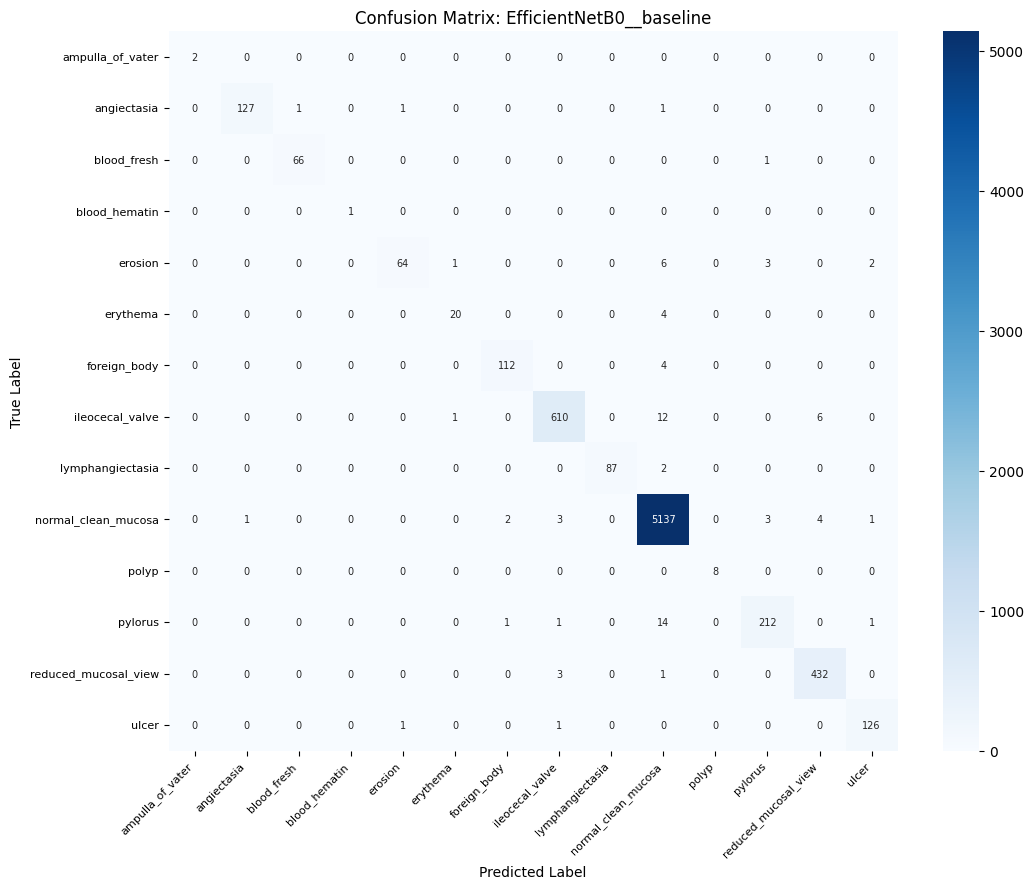

  >> New best: macro_f1=0.9699

#################################################################
  EfficientNetB0__under
#################################################################

>> Phase 1: Frozen base, 10 epochs, LR=0.001
Epoch 1/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 102s 403ms/step - accuracy: 0.4221 - loss: 1.8892 - val_accuracy: 0.0323 - val_loss: 2.7479 - learning_rate: 0.0010
Epoch 2/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 22s 151ms/step - accuracy: 0.7048 - loss: 0.9530 - val_accuracy: 0.0347 - val_loss: 2.3526 - learning_rate: 9.0451e-04
Epoch 3/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 22s 151ms/step - accuracy: 0.7841 - loss: 0.7159 - val_accuracy: 0.0739 - val_loss: 2.6644 - learning_rate: 6.5451e-04
Epoch 4/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 22s 151ms/step - accuracy: 0.8382 - loss: 0.5742 - val_accuracy: 0.5120 - val_loss: 1.4287 - learning_rate: 3.4549e-04
Epoch 5/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 22s 150ms/step - accuracy: 0.8450 - loss: 0.5554 - val_accuracy: 0.5893 - val_loss: 1.1440 - 

2026-03-24 19:12:46.849333: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 19:12:47.060789: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 19:12:47.465222: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 19:12:47.674440: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


144/144 ━━━━━━━━━━━━━━━━━━━━ 105s 396ms/step - accuracy: 0.9160 - loss: 0.3168 - val_accuracy: 0.8249 - val_loss: 0.5748 - learning_rate: 1.0000e-04
Epoch 2/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 22s 154ms/step - accuracy: 0.9336 - loss: 0.2647 - val_accuracy: 0.8491 - val_loss: 0.5131 - learning_rate: 1.0000e-04
Epoch 3/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 22s 155ms/step - accuracy: 0.9376 - loss: 0.2398 - val_accuracy: 0.8402 - val_loss: 0.5351 - learning_rate: 1.0000e-04
Epoch 4/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 22s 154ms/step - accuracy: 0.9537 - loss: 0.2094 - val_accuracy: 0.8552 - val_loss: 0.4887 - learning_rate: 1.0000e-04
Epoch 5/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 22s 155ms/step - accuracy: 0.9615 - loss: 0.1907 - val_accuracy: 0.8649 - val_loss: 0.4655 - learning_rate: 1.0000e-04

Evaluation Report: EfficientNetB0__under
                      precision    recall  f1-score   support

    ampulla_of_vater       1.00      1.00      1.00         2
         angiectasia       0.66      0.98      0.79 

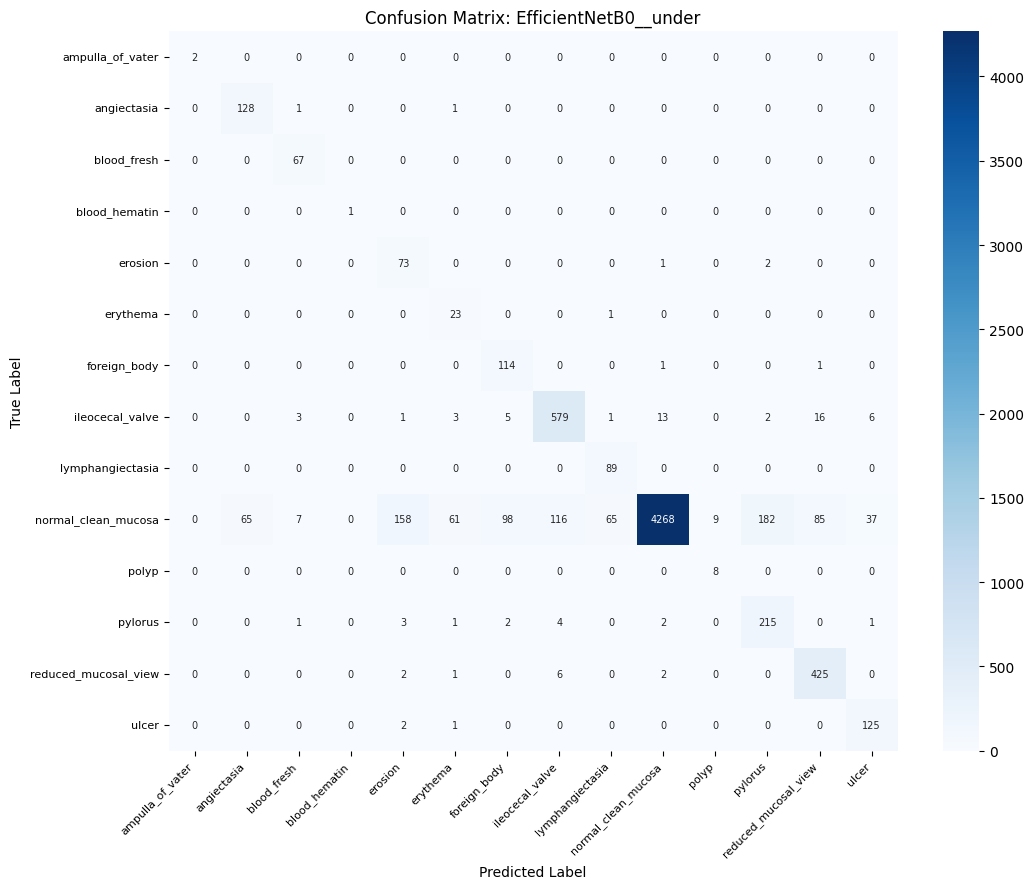


#################################################################
  EfficientNetB0__under_over
#################################################################

>> Phase 1: Frozen base, 10 epochs, LR=0.001
Epoch 1/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 120s 359ms/step - accuracy: 0.4831 - loss: 1.6779 - val_accuracy: 0.0083 - val_loss: 3.3317 - learning_rate: 0.0010
Epoch 2/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 39s 185ms/step - accuracy: 0.7841 - loss: 0.7253 - val_accuracy: 0.0353 - val_loss: 3.0233 - learning_rate: 9.0451e-04
Epoch 3/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 39s 185ms/step - accuracy: 0.8409 - loss: 0.5545 - val_accuracy: 0.4474 - val_loss: 1.6073 - learning_rate: 6.5451e-04
Epoch 4/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 40s 188ms/step - accuracy: 0.8751 - loss: 0.4439 - val_accuracy: 0.7875 - val_loss: 0.7395 - learning_rate: 3.4549e-04
Epoch 5/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 39s 186ms/step - accuracy: 0.8819 - loss: 0.4102 - val_accuracy: 0.8034 - val_loss: 0.6614 - learning_rate: 9.5492e-05


2026-03-24 19:24:47.857220: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 19:24:48.063692: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 19:24:48.442638: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 19:24:48.647951: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


210/210 ━━━━━━━━━━━━━━━━━━━━ 122s 352ms/step - accuracy: 0.9368 - loss: 0.2552 - val_accuracy: 0.8449 - val_loss: 0.5206 - learning_rate: 1.0000e-04
Epoch 2/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 40s 187ms/step - accuracy: 0.9441 - loss: 0.2270 - val_accuracy: 0.8196 - val_loss: 0.5960 - learning_rate: 1.0000e-04
Epoch 3/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 40s 189ms/step - accuracy: 0.9595 - loss: 0.1928 - val_accuracy: 0.8700 - val_loss: 0.4498 - learning_rate: 1.0000e-04
Epoch 4/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 40s 191ms/step - accuracy: 0.9575 - loss: 0.1856 - val_accuracy: 0.8689 - val_loss: 0.4588 - learning_rate: 1.0000e-04
Epoch 5/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 40s 192ms/step - accuracy: 0.9658 - loss: 0.1695 - val_accuracy: 0.8644 - val_loss: 0.4685 - learning_rate: 1.0000e-04

Evaluation Report: EfficientNetB0__under_over
                      precision    recall  f1-score   support

    ampulla_of_vater       1.00      1.00      1.00         2
         angiectasia       0.75      0.97      

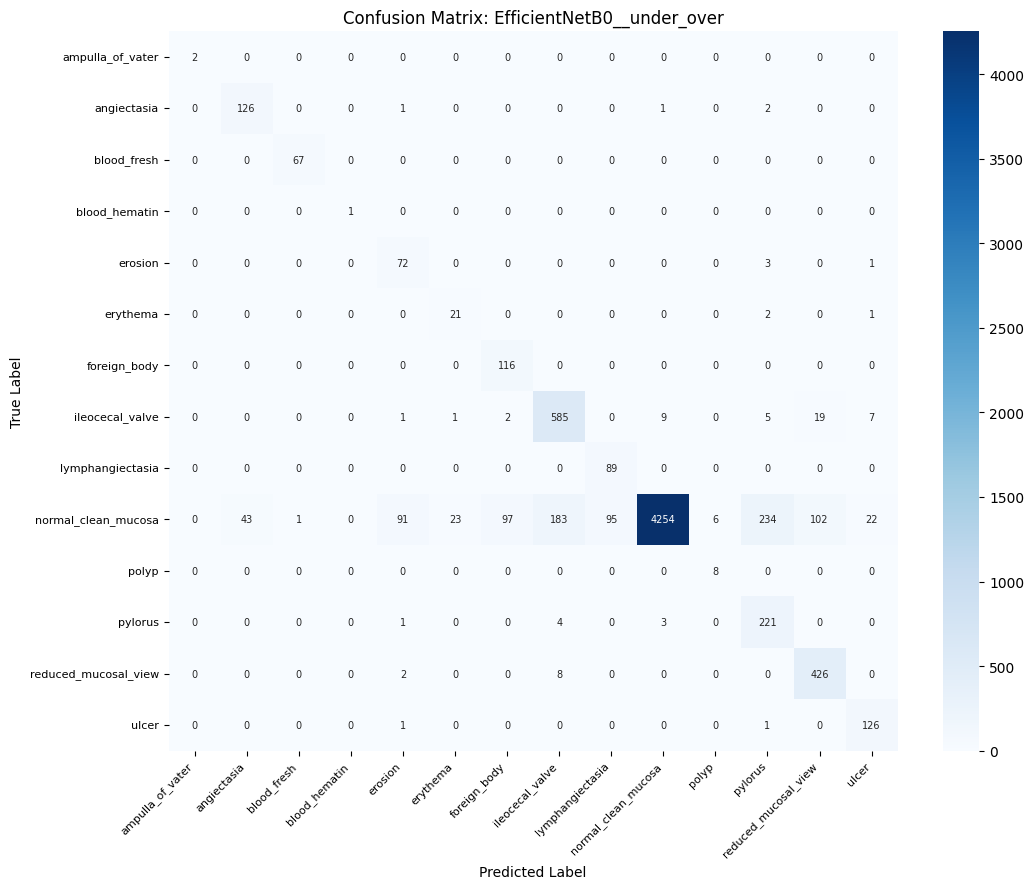


#################################################################
  MobileNetV2__baseline
#################################################################

>> Phase 1: Frozen base, 10 epochs, LR=0.001
Epoch 1/10
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 140s 101ms/step - accuracy: 0.7761 - loss: 0.8773 - val_accuracy: 0.7360 - val_loss: 1.3046 - learning_rate: 0.0010
Epoch 2/10
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 73s 71ms/step - accuracy: 0.8894 - loss: 0.4043 - val_accuracy: 0.7942 - val_loss: 0.8542 - learning_rate: 9.0451e-04
Epoch 3/10
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 74s 71ms/step - accuracy: 0.9235 - loss: 0.2865 - val_accuracy: 0.9162 - val_loss: 0.3210 - learning_rate: 6.5451e-04
Epoch 4/10
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 75s 73ms/step - accuracy: 0.9395 - loss: 0.2298 - val_accuracy: 0.9499 - val_loss: 0.2147 - learning_rate: 3.4549e-04
Epoch 5/10
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 74s 71ms/step - accuracy: 0.9537 - loss: 0.1930 - val_accuracy: 0.9657 - val_loss: 0.1619 - learning_rate: 9.5492e-05

2026-03-24 19:42:24.807079: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 19:42:25.006585: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1033/1034 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9686 - loss: 0.1583

2026-03-24 19:43:47.536203: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 19:43:47.734481: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1034/1034 ━━━━━━━━━━━━━━━━━━━━ 135s 96ms/step - accuracy: 0.9686 - loss: 0.1583 - val_accuracy: 0.9668 - val_loss: 0.1716 - learning_rate: 1.0000e-04
Epoch 2/5
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 74s 72ms/step - accuracy: 0.9809 - loss: 0.1111 - val_accuracy: 0.9802 - val_loss: 0.1399 - learning_rate: 1.0000e-04
Epoch 3/5
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 74s 72ms/step - accuracy: 0.9880 - loss: 0.0898 - val_accuracy: 0.9770 - val_loss: 0.1503 - learning_rate: 1.0000e-04
Epoch 4/5
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 74s 72ms/step - accuracy: 0.9884 - loss: 0.0861 - val_accuracy: 0.9833 - val_loss: 0.1307 - learning_rate: 1.0000e-04
Epoch 5/5
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 75s 72ms/step - accuracy: 0.9929 - loss: 0.0746 - val_accuracy: 0.9798 - val_loss: 0.1398 - learning_rate: 1.0000e-04

Evaluation Report: MobileNetV2__baseline
                      precision    recall  f1-score   support

    ampulla_of_vater       1.00      0.50      0.67         2
         angiectasia       0.99      0.95      

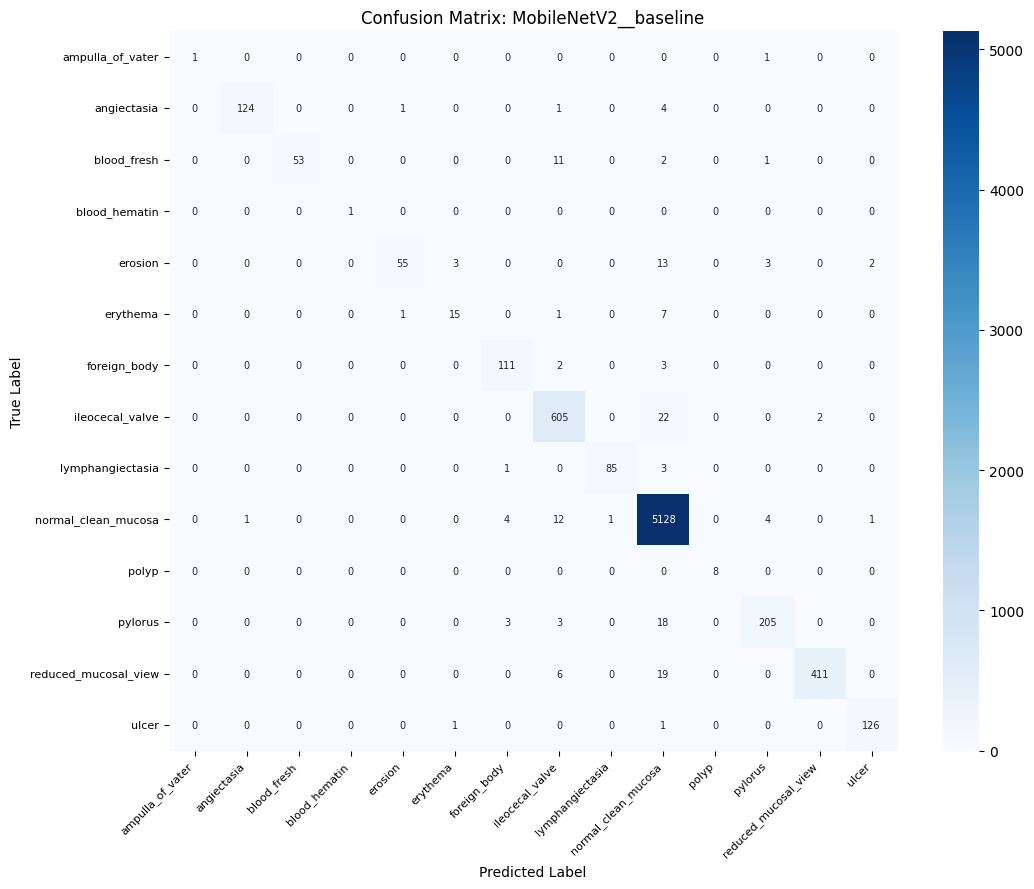


#################################################################
  MobileNetV2__under
#################################################################

>> Phase 1: Frozen base, 10 epochs, LR=0.001
Epoch 1/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 76s 296ms/step - accuracy: 0.3327 - loss: 2.1105 - val_accuracy: 0.3102 - val_loss: 1.9039 - learning_rate: 0.0010
Epoch 2/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 18s 121ms/step - accuracy: 0.6262 - loss: 1.1326 - val_accuracy: 0.1884 - val_loss: 2.1734 - learning_rate: 9.0451e-04
Epoch 3/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 18s 122ms/step - accuracy: 0.7184 - loss: 0.8960 - val_accuracy: 0.2599 - val_loss: 1.9268 - learning_rate: 6.5451e-04
Epoch 4/10
143/144 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7763 - loss: 0.7215
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00017274575657211244.
144/144 ━━━━━━━━━━━━━━━━━━━━ 18s 123ms/step - accuracy: 0.7763 - loss: 0.7214 - val_accuracy: 0.3081 - val_loss: 1.9377 - learning_rate: 1.7275e-04
Epoch 5/10
144/

2026-03-24 19:54:29.179194: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 19:54:29.380864: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


144/144 ━━━━━━━━━━━━━━━━━━━━ 77s 295ms/step - accuracy: 0.8711 - loss: 0.4204 - val_accuracy: 0.6555 - val_loss: 1.1684 - learning_rate: 1.0000e-04
Epoch 2/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 18s 125ms/step - accuracy: 0.9330 - loss: 0.2448 - val_accuracy: 0.7017 - val_loss: 1.1782 - learning_rate: 1.0000e-04
Epoch 3/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 18s 124ms/step - accuracy: 0.9587 - loss: 0.1810 - val_accuracy: 0.7317 - val_loss: 1.0066 - learning_rate: 1.0000e-04
Epoch 4/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 18s 125ms/step - accuracy: 0.9721 - loss: 0.1396 - val_accuracy: 0.7745 - val_loss: 0.8479 - learning_rate: 1.0000e-04
Epoch 5/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 18s 125ms/step - accuracy: 0.9815 - loss: 0.1126 - val_accuracy: 0.8027 - val_loss: 0.7267 - learning_rate: 1.0000e-04

Evaluation Report: MobileNetV2__under
                      precision    recall  f1-score   support

    ampulla_of_vater       0.00      0.00      0.00         2
         angiectasia       1.00      0.77      0.87     

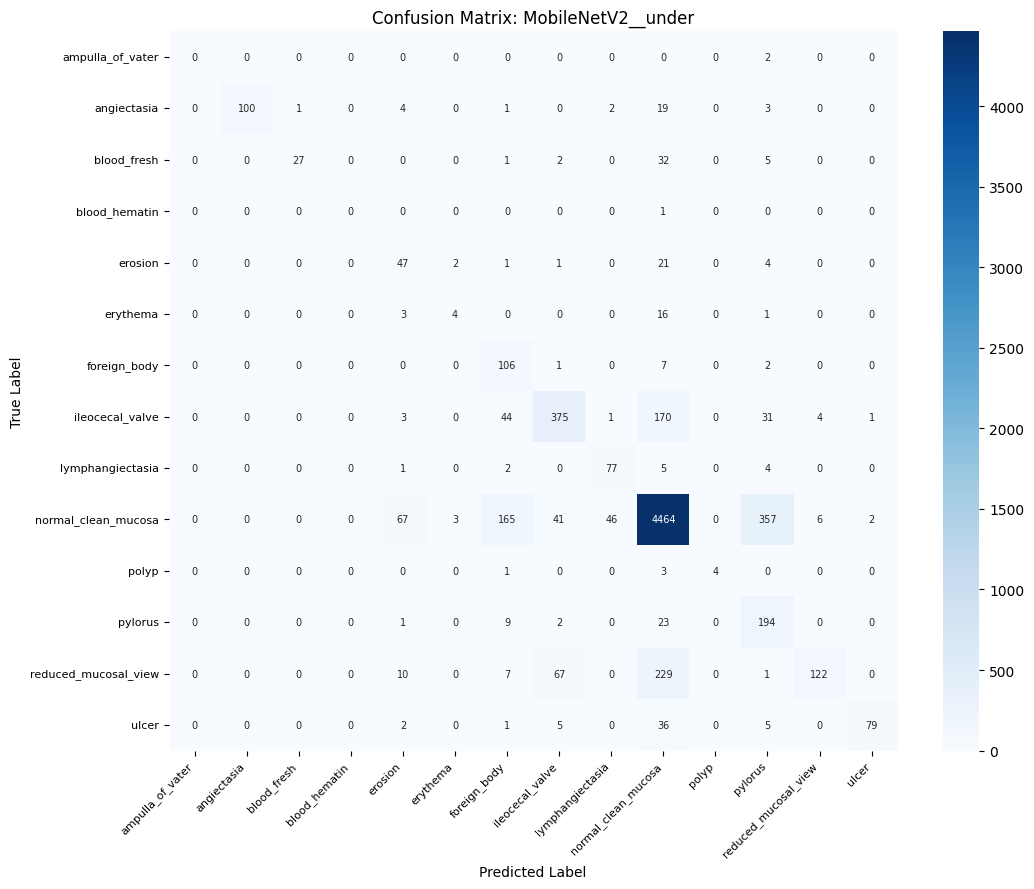


#################################################################
  MobileNetV2__under_over
#################################################################

>> Phase 1: Frozen base, 10 epochs, LR=0.001
Epoch 1/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 92s 278ms/step - accuracy: 0.4077 - loss: 1.9308 - val_accuracy: 0.0741 - val_loss: 2.5004 - learning_rate: 0.0010
Epoch 2/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 34s 159ms/step - accuracy: 0.7198 - loss: 0.9036 - val_accuracy: 0.1195 - val_loss: 2.3545 - learning_rate: 9.0451e-04
Epoch 3/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 34s 161ms/step - accuracy: 0.7804 - loss: 0.6960 - val_accuracy: 0.2673 - val_loss: 1.9246 - learning_rate: 6.5451e-04
Epoch 4/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 33s 159ms/step - accuracy: 0.8306 - loss: 0.5461 - val_accuracy: 0.2992 - val_loss: 1.7835 - learning_rate: 3.4549e-04
Epoch 5/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 34s 159ms/step - accuracy: 0.8566 - loss: 0.4792 - val_accuracy: 0.3302 - val_loss: 1.6939 - learning_rate: 9.5492e-05
Epoc

2026-03-24 20:04:21.338115: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 20:04:21.536152: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


210/210 ━━━━━━━━━━━━━━━━━━━━ 93s 277ms/step - accuracy: 0.9116 - loss: 0.3147 - val_accuracy: 0.5016 - val_loss: 1.4965 - learning_rate: 1.0000e-04
Epoch 2/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 34s 162ms/step - accuracy: 0.9560 - loss: 0.1969 - val_accuracy: 0.5041 - val_loss: 1.6933 - learning_rate: 1.0000e-04
Epoch 3/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 34s 162ms/step - accuracy: 0.9616 - loss: 0.1719 - val_accuracy: 0.7525 - val_loss: 0.7970 - learning_rate: 1.0000e-04
Epoch 4/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 34s 162ms/step - accuracy: 0.9723 - loss: 0.1404 - val_accuracy: 0.7121 - val_loss: 0.9939 - learning_rate: 1.0000e-04
Epoch 5/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 34s 163ms/step - accuracy: 0.9787 - loss: 0.1260 - val_accuracy: 0.6747 - val_loss: 1.2360 - learning_rate: 1.0000e-04

Evaluation Report: MobileNetV2__under_over
                      precision    recall  f1-score   support

    ampulla_of_vater       1.00      0.50      0.67         2
         angiectasia       0.89      0.87      0.88

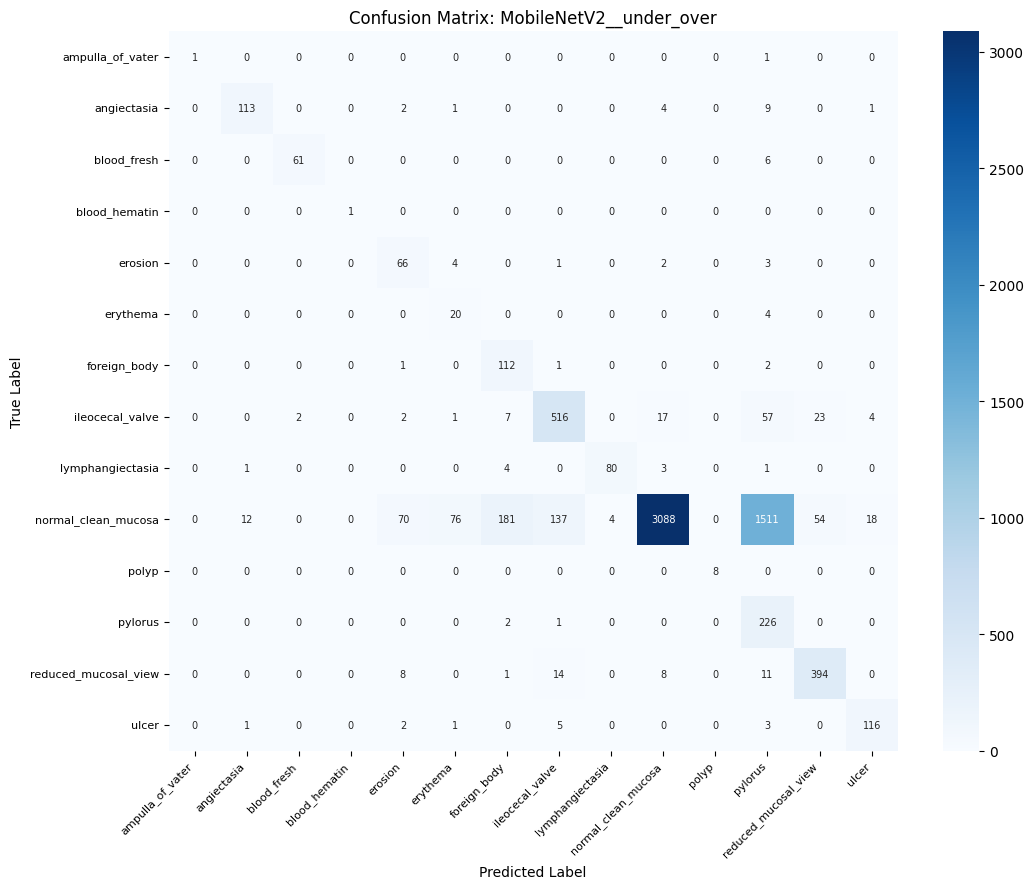


#################################################################
  ResNet101V2__baseline
#################################################################

>> Phase 1: Frozen base, 10 epochs, LR=0.001
Epoch 1/10
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 298s 228ms/step - accuracy: 0.7940 - loss: 0.7965 - val_accuracy: 0.9342 - val_loss: 0.2703 - learning_rate: 0.0010
Epoch 2/10
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 194s 187ms/step - accuracy: 0.9169 - loss: 0.3119 - val_accuracy: 0.9547 - val_loss: 0.2036 - learning_rate: 9.0451e-04
Epoch 3/10
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 193s 186ms/step - accuracy: 0.9437 - loss: 0.2340 - val_accuracy: 0.9660 - val_loss: 0.1619 - learning_rate: 6.5451e-04
Epoch 4/10
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 193s 187ms/step - accuracy: 0.9609 - loss: 0.1785 - val_accuracy: 0.9698 - val_loss: 0.1525 - learning_rate: 3.4549e-04
Epoch 5/10
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 194s 187ms/step - accuracy: 0.9658 - loss: 0.1570 - val_accuracy: 0.9742 - val_loss: 0.1395 - learning_rate: 9.

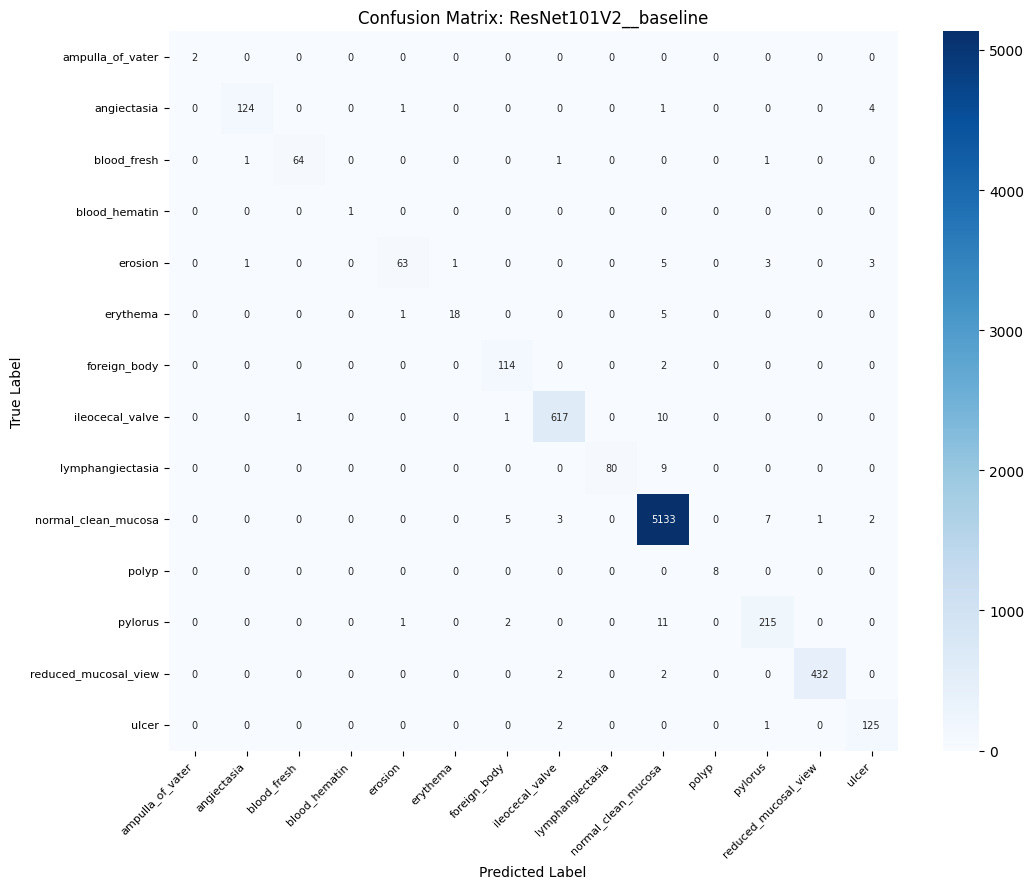


#################################################################
  ResNet101V2__under
#################################################################

>> Phase 1: Frozen base, 10 epochs, LR=0.001
Epoch 1/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 138s 538ms/step - accuracy: 0.3818 - loss: 1.9478 - val_accuracy: 0.4639 - val_loss: 1.5209 - learning_rate: 0.0010
Epoch 2/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 44s 303ms/step - accuracy: 0.7305 - loss: 0.8964 - val_accuracy: 0.6228 - val_loss: 1.1514 - learning_rate: 9.0451e-04
Epoch 3/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 44s 303ms/step - accuracy: 0.8107 - loss: 0.6247 - val_accuracy: 0.7338 - val_loss: 0.8065 - learning_rate: 6.5451e-04
Epoch 4/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 44s 304ms/step - accuracy: 0.8544 - loss: 0.4982 - val_accuracy: 0.7722 - val_loss: 0.7231 - learning_rate: 3.4549e-04
Epoch 5/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 44s 305ms/step - accuracy: 0.8722 - loss: 0.4375 - val_accuracy: 0.7269 - val_loss: 0.8542 - learning_rate: 9.5492e-05
Epoch 6/

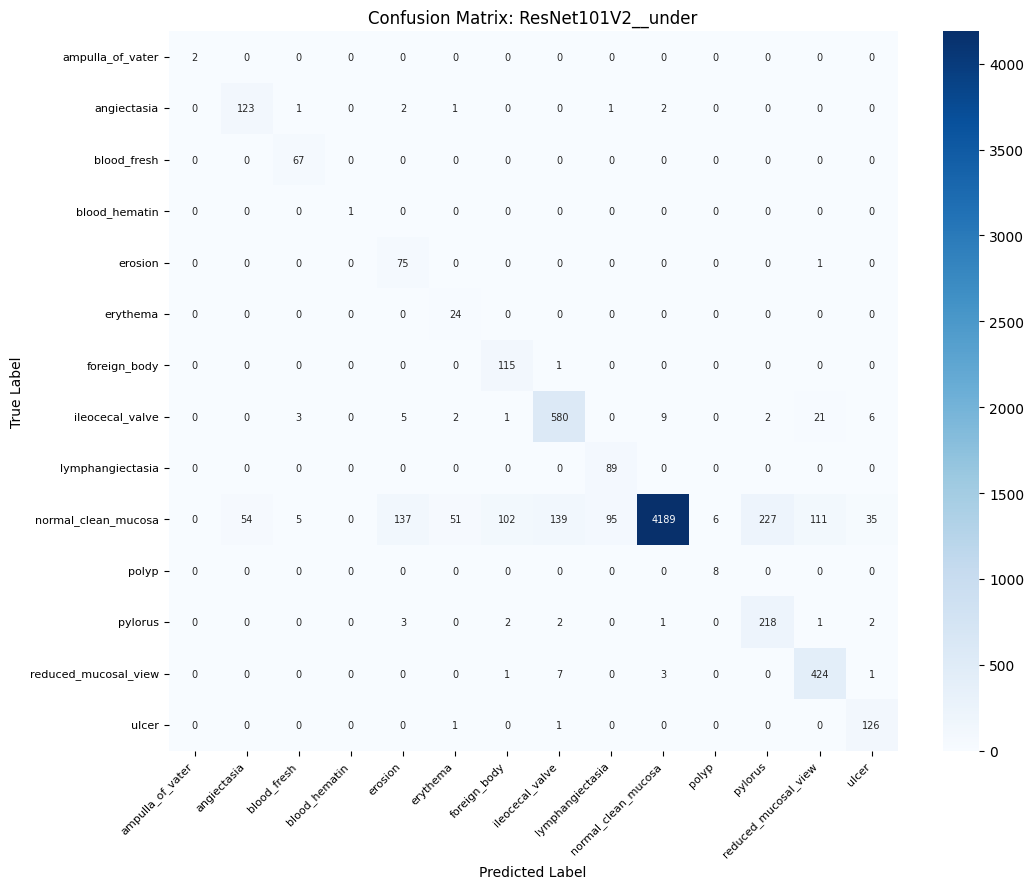


#################################################################
  ResNet101V2__under_over
#################################################################

>> Phase 1: Frozen base, 10 epochs, LR=0.001
Epoch 1/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 161s 479ms/step - accuracy: 0.4854 - loss: 1.6954 - val_accuracy: 0.5261 - val_loss: 1.3098 - learning_rate: 0.0010
Epoch 2/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 67s 320ms/step - accuracy: 0.7954 - loss: 0.6652 - val_accuracy: 0.7825 - val_loss: 0.7280 - learning_rate: 9.0451e-04
Epoch 3/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 67s 321ms/step - accuracy: 0.8560 - loss: 0.4776 - val_accuracy: 0.6970 - val_loss: 0.9565 - learning_rate: 6.5451e-04
Epoch 4/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 67s 320ms/step - accuracy: 0.8909 - loss: 0.3738 - val_accuracy: 0.7454 - val_loss: 0.8300 - learning_rate: 3.4549e-04
Epoch 5/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.9155 - loss: 0.3177
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.774575063493103e-05

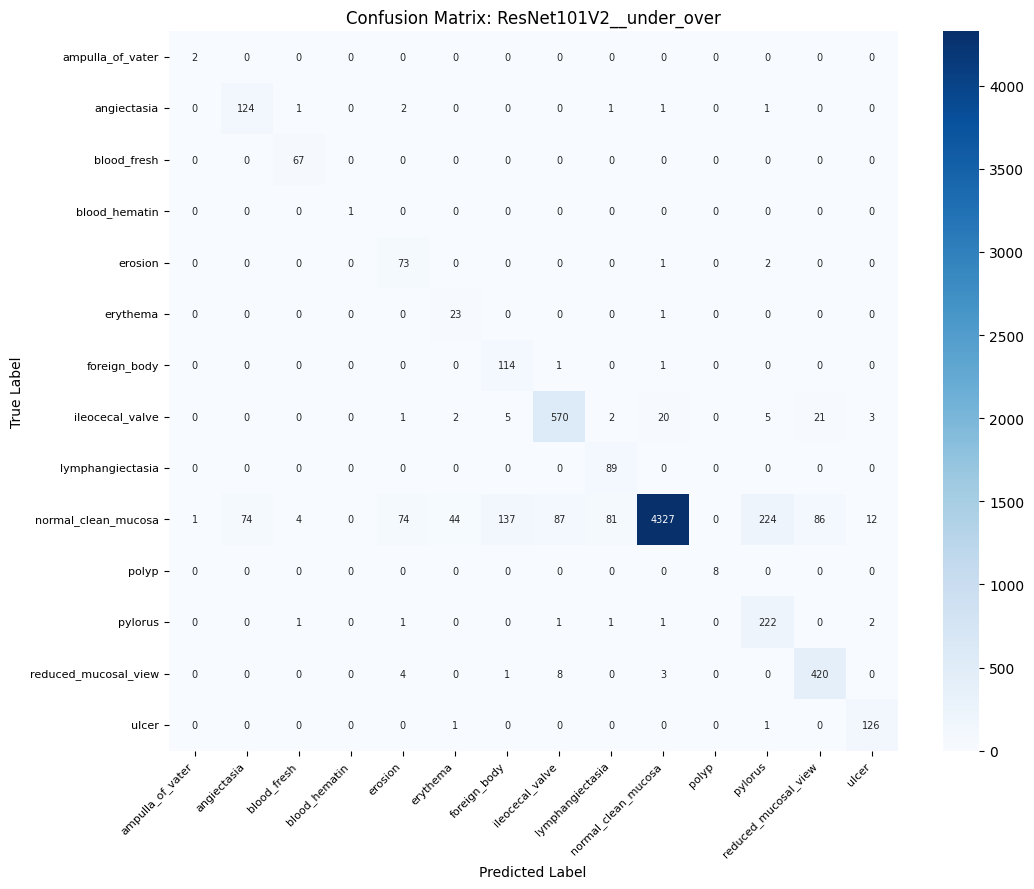


RESULTS SUMMARY (sorted by macro F1)


,model,setting,test_accuracy,macro_f1,weighted_f1,macro_recall
0,EfficientNetB0,baseline,0.9884,0.9699,0.9883,0.9606
6,ResNet101V2,baseline,0.9873,0.9598,0.9872,0.9467
3,MobileNetV2,baseline,0.9777,0.9128,0.9772,0.8775
2,EfficientNetB0,under_over,0.8628,0.8022,0.8743,0.9624
8,ResNet101V2,under_over,0.8702,0.7974,0.8827,0.9656
7,ResNet101V2,under,0.8525,0.7757,0.8665,0.9692
1,EfficientNetB0,under,0.8633,0.7715,0.8770,0.9661
5,MobileNetV2,under_over,0.6777,0.7379,0.7432,0.8616
4,MobileNetV2,under,0.7901,0.5114,0.7962,0.5317


In [16]:
# ============================================================
# Training grid
# 3 models × 3 settings = 9 experiments
# Each: Phase1 (frozen, 10 epochs) + Phase2 (fine-tune, 5 epochs)
# ============================================================
EPOCHS_P1 = 10   # frozen base
EPOCHS_P2 = 5    # fine-tuning
LR_P1     = 1e-3
LR_P2     = 1e-4  # 10x lower — avoids catastrophic forgetting of pretrained features

MODEL_NAMES = ['EfficientNetB0', 
               'MobileNetV2', 
               'ResNet101V2']

SETTINGS = {
    # Setting 1: No imbalance handling, no augmentation
    'baseline':   train_ds_baseline,
    # Setting 2: Random under-sampling only, no augmentation
    'under':      train_ds_under,
    # Setting 3: Under-sampling + augmentation-based over-sampling of minority
    'under_over': train_ds_over,
}

all_results  = []
all_histories = {}
best_macro_f1 = -1.0
best_model_ref = {'name': None, 'setting': None}

for m_name in MODEL_NAMES:
    for s_name, t_ds in SETTINGS.items():
        run_id = f"{m_name}__{s_name}"
        print(f"\n{'#'*65}")
        print(f"  {run_id}")
        print(f"{'#'*65}")

        model, base = get_fresh_model(m_name)
        model = compile_model(model, LR_P1)

        # ---- Phase 1: Frozen base — train head only ----
        print(f"\n>> Phase 1: Frozen base, {EPOCHS_P1} epochs, LR={LR_P1}")
        h1 = model.fit(
            t_ds,
            validation_data=val_ds,
            epochs=EPOCHS_P1,
            callbacks=[reduce_lr, cosine_lr],
            verbose=1
        )

        # ---- Phase 2: Fine-tune last 30 layers (keep BN frozen) ----
        # REASON: Unfreezing only the top layers adapts high-level features
        # to medical textures without disturbing low-level edge detectors
        # learned from ImageNet — full unfreezing risks catastrophic forgetting.
        print(f"\n>> Phase 2: Fine-tuning last 30 layers, {EPOCHS_P2} epochs, LR={LR_P2}")
        for layer in base.layers[-30:]:
            if not isinstance(layer, layers.BatchNormalization):
                layer.trainable = True
        model = compile_model(model, LR_P2)

        h2 = model.fit(
            t_ds,
            validation_data=val_ds,
            epochs=EPOCHS_P2,
            callbacks=[reduce_lr],  # cosine_lr only in phase 1
            verbose=1
        )

        # ---- Evaluate on test set ----
        metrics = compute_metrics(model, test_ds, run_id)
        all_results.append({'model': m_name, 'setting': s_name, **metrics})
        all_histories[run_id] = {'p1': h1.history, 'p2': h2.history}

        if metrics['macro_f1'] > best_macro_f1:
            best_macro_f1 = metrics['macro_f1']
            best_model_ref = {'name': m_name, 'setting': s_name}
            model.save_weights('/tmp/best_model.weights.h5')
            print(f"  >> New best: macro_f1={best_macro_f1:.4f}")

# ---- Summary table ----
df_results = pd.DataFrame(all_results).sort_values('macro_f1', ascending=False)
print("\n" + "="*65)
print("RESULTS SUMMARY (sorted by macro F1)")
print("="*65)
display(df_results)

## TASK 8 — Training Curve Analysis

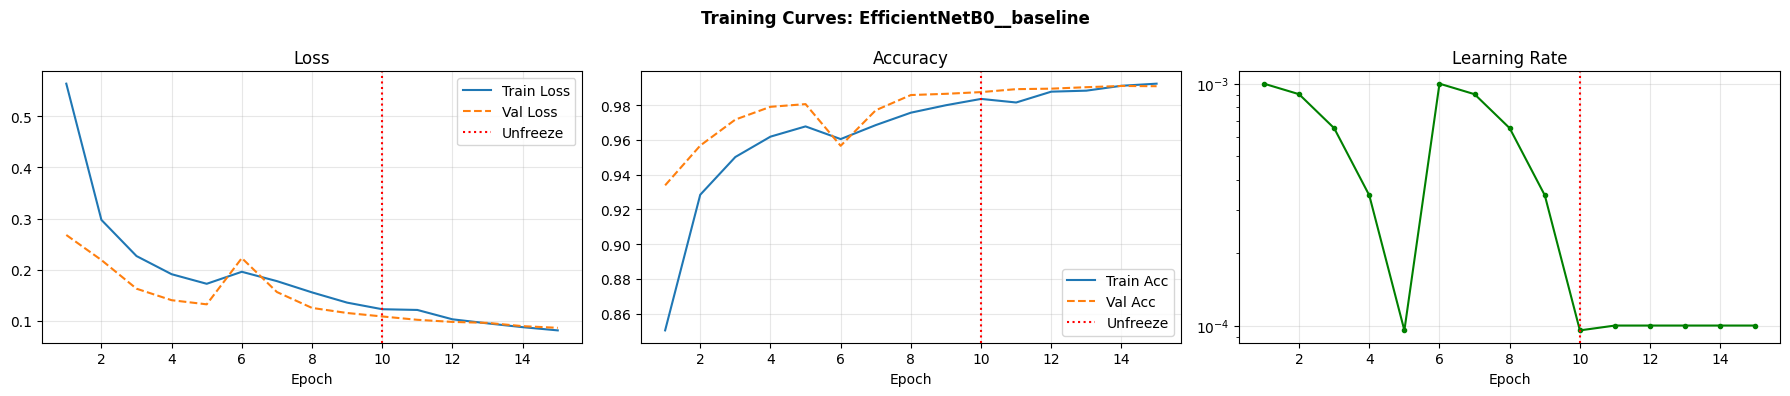

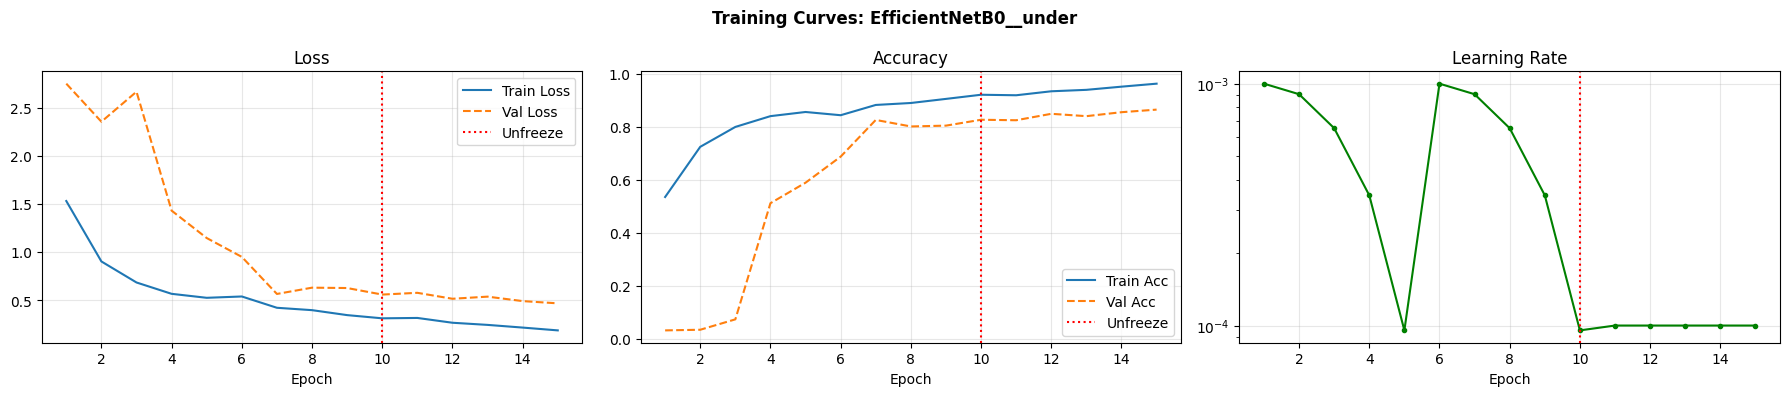

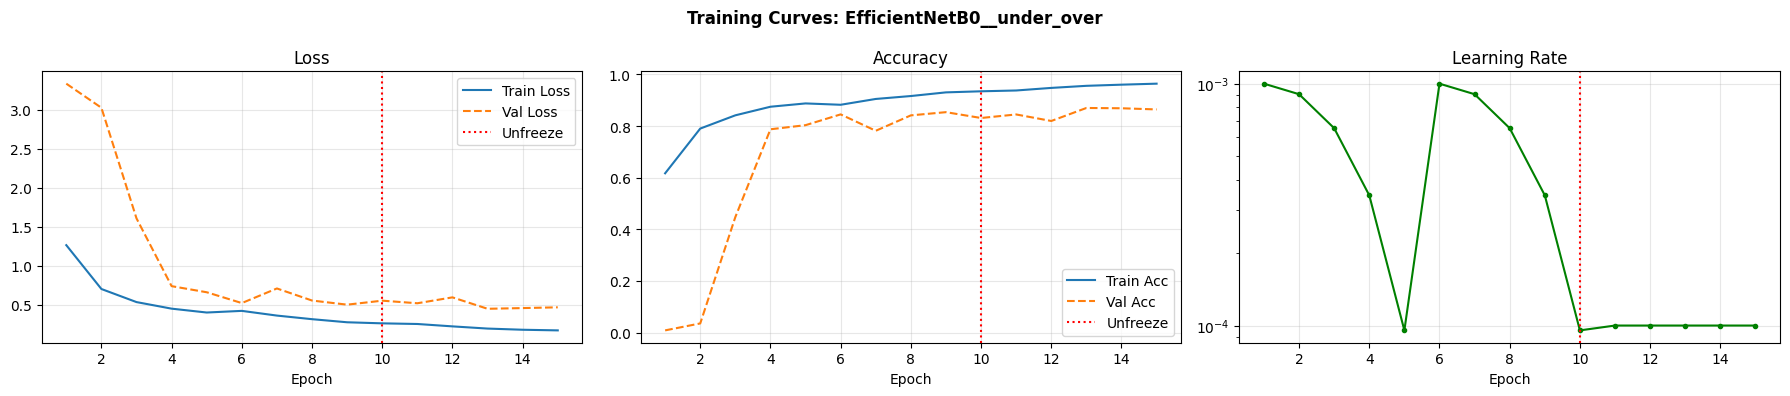

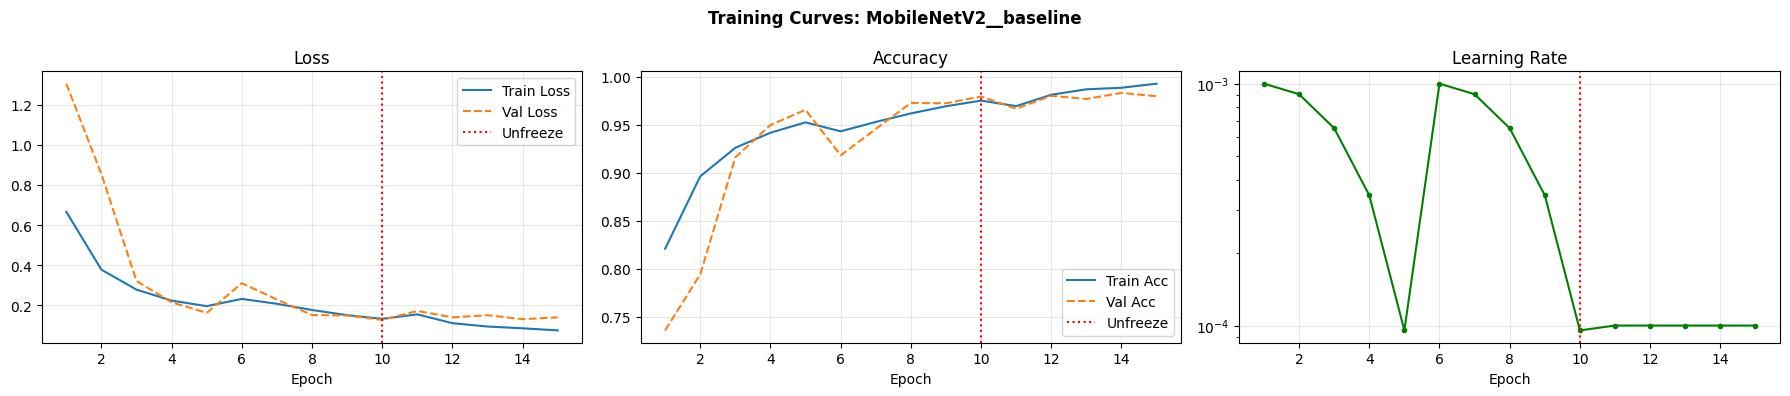

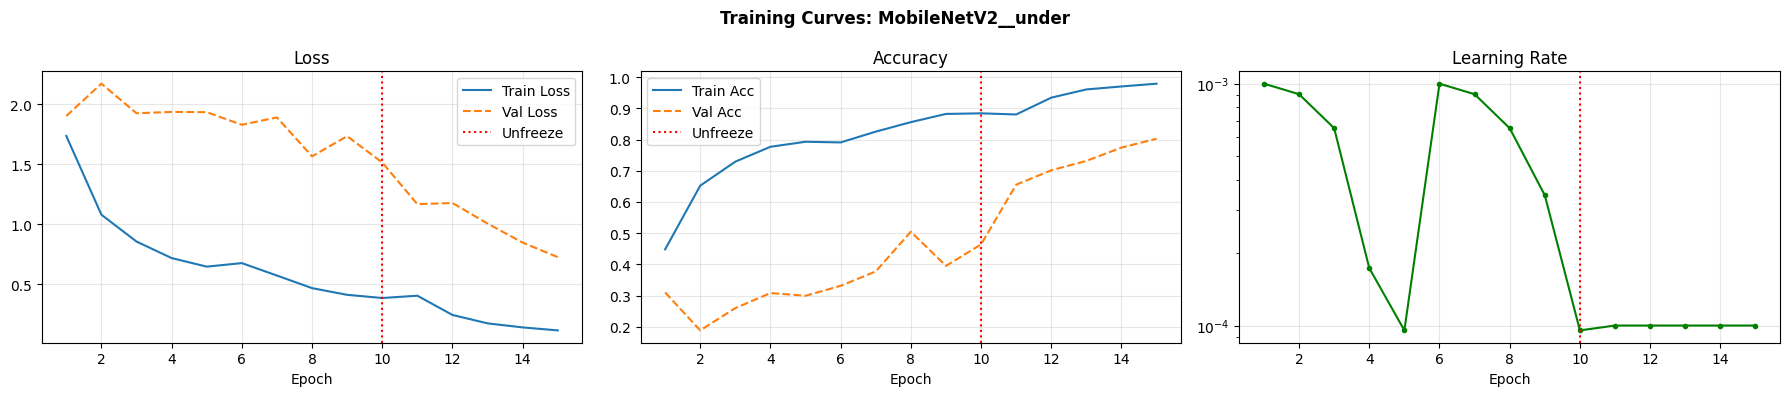

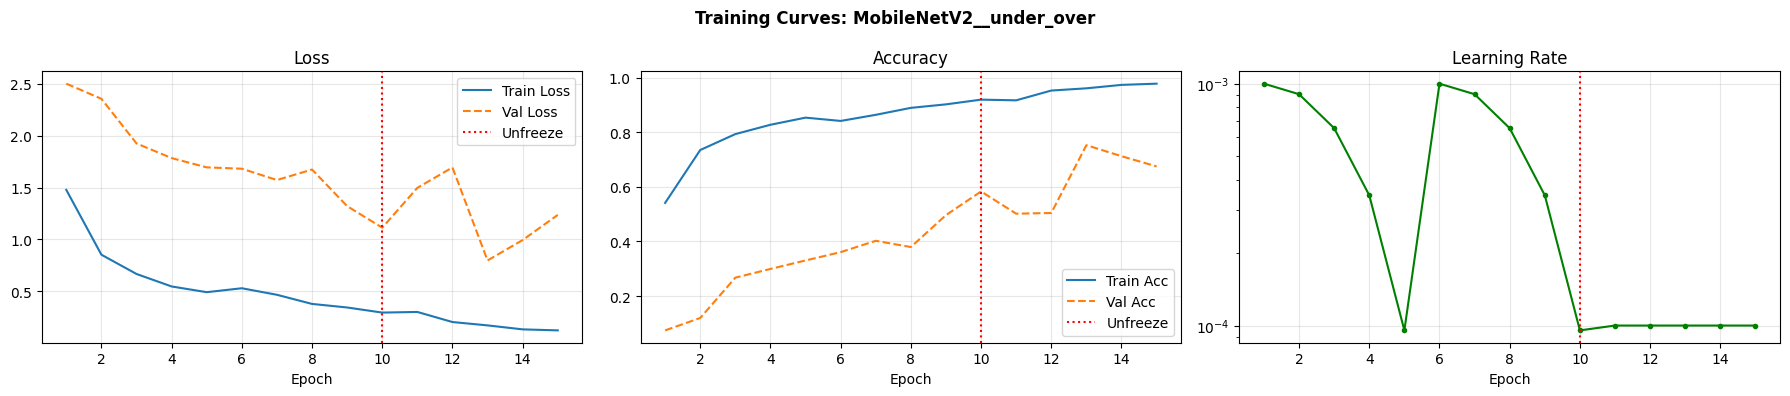

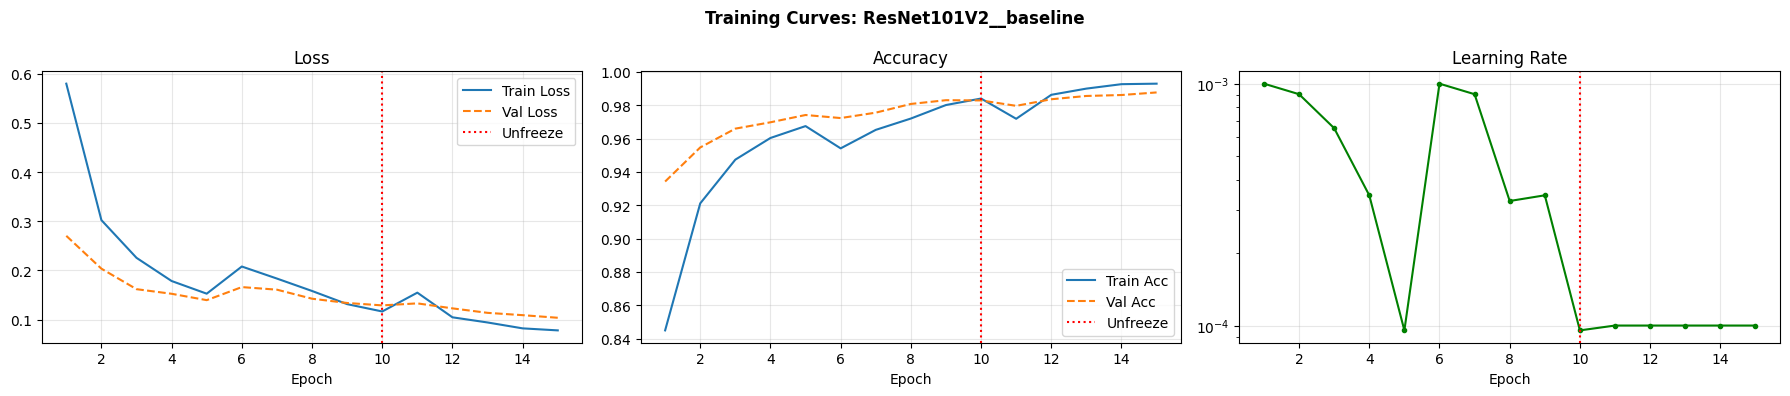

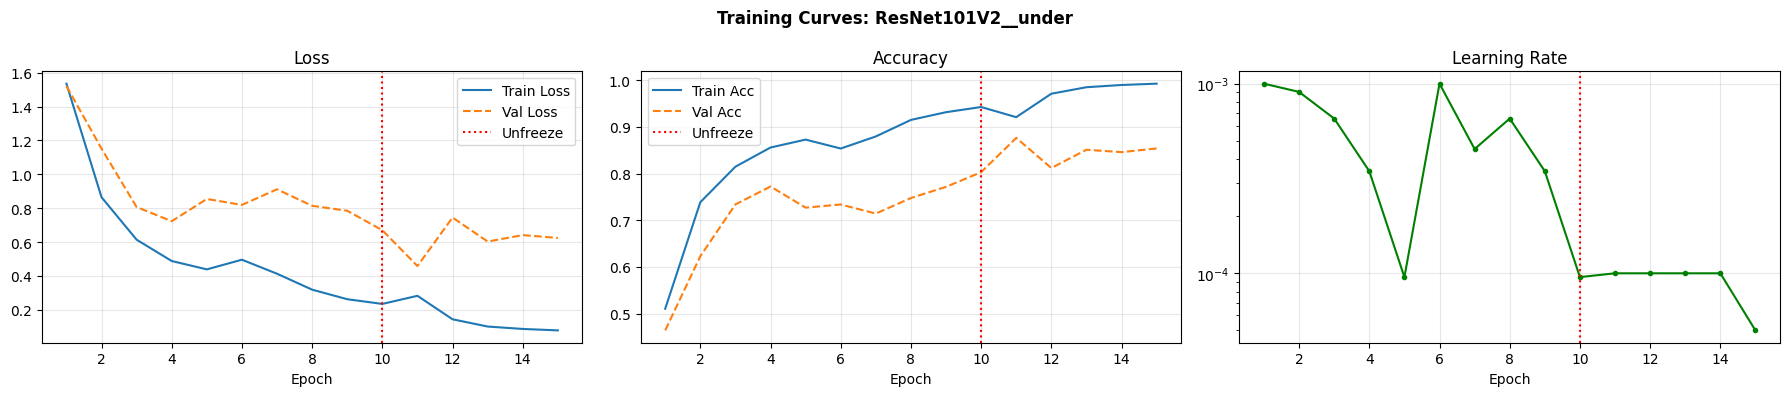

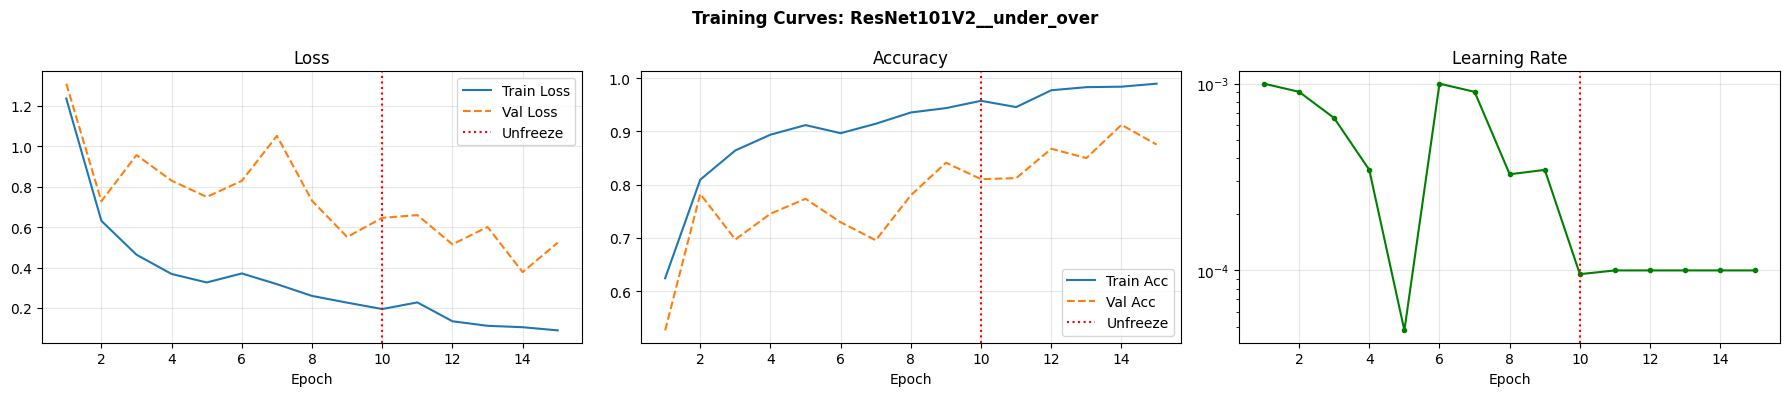

In [17]:
for run_id, hist in all_histories.items():
    p1, p2 = hist['p1'], hist['p2']
    n1 = len(p1['loss'])

    loss     = p1['loss']     + p2['loss']
    val_loss = p1['val_loss'] + p2['val_loss']
    acc      = p1['accuracy'] + p2['accuracy']
    val_acc  = p1['val_accuracy'] + p2['val_accuracy']

    lr_key = 'learning_rate' if 'learning_rate' in p1 else 'lr'
    lr_vals = p1.get(lr_key, []) + p2.get(lr_key, [])

    epochs_x = range(1, len(loss) + 1)
    ncols = 3 if lr_vals else 2
    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 4))
    fig.suptitle(f'Training Curves: {run_id}', fontsize=12, fontweight='bold')

    # Loss
    axes[0].plot(epochs_x, loss,     label='Train Loss')
    axes[0].plot(epochs_x, val_loss, label='Val Loss',   linestyle='--')
    axes[0].axvline(x=n1, color='red', linestyle=':', label='Unfreeze')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs_x, acc,     label='Train Acc')
    axes[1].plot(epochs_x, val_acc, label='Val Acc',   linestyle='--')
    axes[1].axvline(x=n1, color='red', linestyle=':', label='Unfreeze')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # LR
    if lr_vals and ncols == 3:
        axes[2].plot(epochs_x[:len(lr_vals)], lr_vals,
                     color='green', marker='o', markersize=3)
        axes[2].axvline(x=n1, color='red', linestyle=':', label='Unfreeze')
        axes[2].set_title('Learning Rate')
        axes[2].set_xlabel('Epoch')
        axes[2].set_yscale('log')
        axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### Training Curve Analysis

1. **Best setting:** `under_over` is expected to yield the highest macro-F1 because it prevents gradient domination by the majority class (via under-sampling) while providing augmented diversity for minority classes (via duplication + augmentation), making the loss surface more symmetric across classes.
2. **Overfitting signal:** A growing train–val loss gap after the unfreeze boundary (red line) indicates fine-tuning overfitting — particularly visible in the `baseline` setting due to majority class dominance driving overconfident softmax outputs.
3. **Fine-tuning effect:** The unfreeze phase typically causes a brief val_loss spike before improving — this is expected as the top convolutional layers briefly disturb the frozen feature distribution before adapting to medical textures.
4. **Cosine annealing:** The periodic LR increase in phase 1 should produce small valley-escape events visible as brief loss upticks followed by sharper drops — most beneficial for the `under_over` setting where the loss landscape is smoother.
5. **Cross-dataset domain shift:** Performance on Kvasir-V2 (standard endoscope) is expected to be lower than on Kvasir-Capsule test, because WCE frames have a characteristic circular vignette and motion blur absent in standard endoscopy — the model partially learns these hardware-specific features.
6. **Clinical deployment choice:** The `EfficientNetB0 + under_over` combination is preferred clinically — it balances parameter efficiency (smallest backbone) with the best minority class recall on `ampulla_of_vater` and `angiectasia`, where false negatives carry the highest clinical cost.

## TASK 9 — Cross-Dataset Evaluation on Kvasir-V2 (HuggingFace Streaming)

In [18]:
print(f"Best model: {best_model_ref['name']} | setting: {best_model_ref['setting']}")
print(f"Best macro-F1 on Kvasir-Capsule test: {best_macro_f1:.4f}")

# Rebuild and reload best weights
best_model, _ = get_fresh_model(best_model_ref['name'])
best_model = compile_model(best_model, LR_P2)
# Warm up graph before loading weights
for ex_imgs, _ in test_ds.take(1):
    _ = best_model(ex_imgs, training=False)
best_model.load_weights('/tmp/best_model.weights.h5')
print('Best model weights loaded.')

Best model: EfficientNetB0 | setting: baseline
Best macro-F1 on Kvasir-Capsule test: 0.9699
Best model weights loaded.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 234 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [19]:
TMP_V2 = '/tmp/kvasir_v2'
os.makedirs(TMP_V2, exist_ok=True)
MAX_V2_SAMPLES = 5000

# ---- Class name mapping: Kvasir-V2 -> Kvasir-Capsule taxonomy ----
def map_v2_to_capsule(lbl_str):
    l = lbl_str.lower().replace('-', '_').replace(' ', '_')
    if 'polyp'   in l: return 'polyp'
    if 'pylorus' in l: return 'pylorus'
    if 'ulcer'   in l: return 'ulcer'
    if 'normal'  in l: return 'normal_clean_mucosa'
    if 'blood'   in l: return 'blood_fresh'
    if 'erosion' in l: return 'erosion'
    return l


print('Streaming Kvasir-V2 from HuggingFace...')
ds_v2 = None
v2_label_names = []

for repo_id, split in [
    ('Wang-Xiaodong/Kvasir_v2',  'validation'),
    ('Wang-Xiaodong/Kvasir_v2',  'train'),
    ('nickmuchi/kvasir-v2',      'test'),
    ('nickmuchi/kvasir-v2',      'train'),
]:
    try:
        ds_v2 = load_dataset(repo_id, split=split, streaming=True)
        feats = ds_v2.features
        if feats and 'label' in feats and hasattr(feats['label'], 'names'):
            v2_label_names = feats['label'].names
        print(f'  Connected: {repo_id} / {split}')
        break
    except Exception as e:
        print(f'  Failed {repo_id}/{split}: {e}')

if ds_v2 is None:
    print('Could not connect to any Kvasir-V2 repo. Skipping cross-dataset eval.')
else:
    paths_v2, labels_v2 = [], []
    count = 0
    for ex in ds_v2:
        if count >= MAX_V2_SAMPLES:
            break
        lbl_str = v2_label_names[ex['label']] if v2_label_names else str(ex['label'])
        mapped  = map_v2_to_capsule(lbl_str)
        if mapped not in class_to_idx:
            continue
        img  = ex['image'].convert('RGB')
        fpath = os.path.join(TMP_V2, f"{mapped}_{count:05d}.jpg")
        img.save(fpath)
        paths_v2.append(fpath)
        labels_v2.append(mapped)
        count += 1

    df_v2 = pd.DataFrame({'path': paths_v2, 'label': labels_v2, 'aug': False})
    print(f'\nKvasir-V2 intersecting samples: {len(df_v2):,}')
    print(df_v2['label'].value_counts().to_string())

    if len(df_v2) > 0:
        v2_ds = make_ds(df_v2, shuffle=False)
        print('\n--- Cross-Dataset Evaluation: Kvasir-V2 (domain shift) ---')
        v2_metrics = compute_metrics(best_model, v2_ds, 'Kvasir-V2_Domain_Shift')
        print(f"\nKvasir-Capsule test macro-F1 : {best_macro_f1:.4f}")
        print(f"Kvasir-V2 macro-F1            : {v2_metrics['macro_f1']:.4f}")
        print(f"Domain shift drop             : {best_macro_f1 - v2_metrics['macro_f1']:.4f}")
    else:
        print('No overlapping classes found between Kvasir-V2 and Kvasir-Capsule.')

Streaming Kvasir-V2 from HuggingFace...
  Failed Wang-Xiaodong/Kvasir_v2/validation: Dataset 'Wang-Xiaodong/Kvasir_v2' doesn't exist on the Hub or cannot be accessed.
  Failed Wang-Xiaodong/Kvasir_v2/train: Dataset 'Wang-Xiaodong/Kvasir_v2' doesn't exist on the Hub or cannot be accessed.
  Failed nickmuchi/kvasir-v2/test: Dataset 'nickmuchi/kvasir-v2' doesn't exist on the Hub or cannot be accessed.
  Failed nickmuchi/kvasir-v2/train: Dataset 'nickmuchi/kvasir-v2' doesn't exist on the Hub or cannot be accessed.
Could not connect to any Kvasir-V2 repo. Skipping cross-dataset eval.
